# USTA Pose — Non-Verbal Communication Vocabulary Discovery
## Unsupervised Clustering Analysis with Statistical Validation

This notebook performs a **publication-quality** unsupervised analysis of dyadic
interaction data from the USTA project (Zincir/Chain task). Two participants sit
across a table and collaboratively build a chain of 18 colored/numbered discs.

**Objective:** Discover recurring non-verbal communication patterns ("behavioral
vocabulary") from pose and gaze data, and provide rigorous statistical evidence
that these patterns are meaningful — without relying on ground-truth video
annotation.

### Theoretical Framework
- **Social Signal Processing** (Vinciarelli et al., 2009)
- **Gaze functions in interaction** (Kendon, 1967)
- **Proxemics** (Hall, 1966)
- **Turn-taking systematics** (Sacks, Schegloff & Jefferson, 1974)
- **Behavioral syllables from keypoints** (Wiltschko et al., 2015; Weinreb et al., 2024)


In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, 
    silhouette_samples,
    davies_bouldin_score, 
    calinski_harabasz_score,
    adjusted_rand_score,
)

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

print("All imports successful.")


All imports successful.


## 1. Data Loading
Load **all** 44 parquet files. Keep only frames where `frame_interaction_valid == True`.


In [2]:
DATA_DIR = "./devel/final_dataset_parquets"
parquet_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
print(f"Found {len(parquet_files)} parquet files.\n")

dfs = []
for f in parquet_files:
    try:
        df = pd.read_parquet(f)
        basename = os.path.basename(f)
        # Inject a session label from filename
        df['session_label'] = basename.replace('.parquet', '')
        # Keep valid interaction frames only
        if 'frame_interaction_valid' in df.columns:
            df = df[df['frame_interaction_valid'] == True]
        dfs.append(df)
        print(f"  {basename}: {len(df):>5} valid frames")
    except Exception as e:
        print(f"  ERROR {f}: {e}")

data = pd.concat(dfs, ignore_index=True)
print(f"\n{'='*50}")
print(f"Total valid frames loaded: {len(data):,}")
print(f"Total sessions: {data['session_label'].nunique()}")
print(f"Total columns : {len(data.columns):,}")


Found 44 parquet files.



  20260504_183351_order1.parquet:  1593 valid frames


  20260504_183529_order2.parquet:  6577 valid frames


  20260504_184034_order3.parquet:  2523 valid frames


  20260504_184304_order4.parquet:  5015 valid frames


...

  20260510_154339_order1.parquet:  2643 valid frames


  20260510_154923_order2.parquet:  2191 valid frames


  20260510_155222_order3.parquet:  2650 valid frames


  20260510_155501_order4.parquet:  1291 valid frames



Total valid frames loaded: 131,907
Total sessions: 44
Total columns : 3,437


## 2. Feature Engineering — Literature-Grounded Feature Set

We select features grounded in the Social Signal Processing literature:

| Domain | Features | Literature Basis |
|--------|----------|-----------------|
| **Gaze / Oculesics** | Mutual gaze (multi-tier: 5°, 10°, 15°), gaze-to-workspace | Kendon (1967); Gamer & Hecht (2007) |
| **Proxemics** | Root distance, head distance, approach velocity | Hall (1966); Argyle & Dean (1965) |
| **Kinesics / Gesture** | Wrist-to-wrist distance, wrist-to-head distance | Hoffman (2019) |
| **Motion / Activity** | Speed, body energy, motion asymmetry ratio | Pentland (2008) |

### Sliding Window Parameters
- **Window size:** 60 frames (~2 seconds at 30 fps)
- **Step size:** 30 frames (50% overlap)


In [3]:
# ── Define the comprehensive feature extraction ──

WINDOW_SIZE = 60   # ~2 seconds
STEP_SIZE   = 30   # 50% overlap

def compute_window_features(w):
    """Compute a rich feature vector for one temporal window."""
    feat = {}
    
    # ═══════════════════════════════════════════════════════
    # A) PROXEMICS — Interpersonal Distance (Hall, 1966)
    # ═══════════════════════════════════════════════════════
    for col in ['dyad_root_distance', 'dyad_root_horizontal_distance',
                'p1_head_to_p2_head_distance']:
        if col in w.columns:
            s = w[col].dropna()
            if len(s) > 1:
                feat[f'{col}_mean'] = s.mean()
                feat[f'{col}_std']  = s.std()
                feat[f'{col}_delta'] = s.iloc[-1] - s.iloc[0]  # approach/withdrawal
    
    # ═══════════════════════════════════════════════════════
    # B) GAZE / OCULESICS — Multi-tier (Kendon 1967; Gamer & Hecht 2007)
    # ═══════════════════════════════════════════════════════
    for person in ['p1', 'p2']:
        col = f'{person}_gaze_to_other_head_angle_deg'
        if col in w.columns:
            s = w[col].dropna()
            if len(s) > 1:
                feat[f'{col}_mean'] = s.mean()
                feat[f'{col}_std']  = s.std()
    
    # Gaze to shared workspace (joint attention)
    for person in ['p1', 'p2']:
        col = f'{person}_gaze_to_dyad_ref_angle_deg'
        if col in w.columns:
            s = w[col].dropna()
            if len(s) > 0:
                feat[f'{col}_mean'] = s.mean()
    
    # Multi-tier mutual gaze ratios
    g1 = w.get('p1_gaze_to_other_head_angle_deg')
    g2 = w.get('p2_gaze_to_other_head_angle_deg')
    if g1 is not None and g2 is not None:
        valid = g1.notna() & g2.notna()
        if valid.sum() > 0:
            g1v, g2v = g1[valid], g2[valid]
            feat['mutual_gaze_strict_ratio']  = ((g1v < 5)  & (g2v < 5)).mean()   # eye contact
            feat['mutual_gaze_medium_ratio']  = ((g1v < 10) & (g2v < 10)).mean()  # face region
            feat['mutual_gaze_loose_ratio']   = ((g1v < 15) & (g2v < 15)).mean()  # oriented toward
    
    # Direct mutual gaze metric from pipeline
    if 'mutual_gaze_cos_min' in w.columns:
        s = w['mutual_gaze_cos_min'].dropna()
        if len(s) > 0:
            feat['mutual_gaze_cos_min_mean'] = s.mean()
            feat['mutual_gaze_cos_min_max']  = s.max()
    
    # ═══════════════════════════════════════════════════════
    # C) KINESICS — Hand/Wrist Distances (Hoffman, 2019)
    # ═══════════════════════════════════════════════════════
    wrist_cols = [
        'p1_left_wrist_to_p2_right_wrist_distance',
        'p1_right_wrist_to_p2_left_wrist_distance',
        'p1_left_wrist_to_p2_head_distance',
        'p1_right_wrist_to_p2_head_distance',
        'p2_left_wrist_to_p1_head_distance',
        'p2_right_wrist_to_p1_head_distance',
    ]
    for col in wrist_cols:
        if col in w.columns:
            s = w[col].dropna()
            if len(s) > 0:
                feat[f'{col}_mean'] = s.mean()
                feat[f'{col}_min']  = s.min()  # closest approach
    
    # Cross-person closest wrist distance (handover indicator)
    w2w_cols = [c for c in wrist_cols[:2] if c in w.columns]
    if w2w_cols:
        min_vals = [w[c].dropna().min() for c in w2w_cols if len(w[c].dropna()) > 0]
        if min_vals:
            feat['cross_wrist_min_distance'] = min(min_vals)
    
    # ═══════════════════════════════════════════════════════
    # D) MOTION / ACTIVITY (Pentland, 2008)
    # ═══════════════════════════════════════════════════════
    for person in ['p1', 'p2']:
        for mcol in [f'{person}_motion_speed', f'{person}_motion_energy_body']:
            if mcol in w.columns:
                s = w[mcol].dropna()
                if len(s) > 1:
                    feat[f'{mcol}_mean'] = s.mean()
                    feat[f'{mcol}_std']  = s.std()
                    feat[f'{mcol}_max']  = s.max()
    
    # Motion asymmetry (turn-taking indicator)
    if 'motion_energy_ratio_p1_over_p2' in w.columns:
        s = w['motion_energy_ratio_p1_over_p2'].replace([np.inf, -np.inf], np.nan).dropna()
        if len(s) > 0:
            # Use log ratio for symmetry: log(1)=0 means equal
            ratios = np.clip(s.values, 0.01, 100)
            feat['motion_log_ratio_mean'] = np.log(ratios).mean()
            feat['motion_log_ratio_std']  = np.log(ratios).std()
    
    return feat


def extract_all_windows(data, window_size=WINDOW_SIZE, step_size=STEP_SIZE):
    """Extract windowed features from all sessions."""
    all_windows = []
    
    sessions = data.groupby('session_label')
    for session_name, session_df in sessions:
        session_df = session_df.sort_values('frame_idx').reset_index(drop=True)
        n = len(session_df)
        
        for start in range(0, n - window_size + 1, step_size):
            end = start + window_size
            w = session_df.iloc[start:end]
            feats = compute_window_features(w)
            feats['session_label'] = session_name
            feats['window_start_frame'] = int(w['frame_idx'].iloc[0])
            feats['window_end_frame']   = int(w['frame_idx'].iloc[-1])
            if 'timestamp_ms' in w.columns:
                ts = w['timestamp_ms'].dropna()
                if len(ts) > 0:
                    feats['window_start_ms'] = float(ts.iloc[0])
                    feats['window_end_ms']   = float(ts.iloc[-1])
            all_windows.append(feats)
    
    return pd.DataFrame(all_windows)


window_df = extract_all_windows(data)
print(f"Extracted {len(window_df):,} temporal windows from {data['session_label'].nunique()} sessions.")
print(f"Feature columns: {len([c for c in window_df.columns if c not in ['session_label','window_start_frame','window_end_frame','window_start_ms','window_end_ms']])} features per window.")
print(f"\nFeature list:")
feat_cols = [c for c in window_df.columns if c not in ['session_label','window_start_frame','window_end_frame','window_start_ms','window_end_ms']]
for i, c in enumerate(feat_cols, 1):
    print(f"  {i:2d}. {c}")


Extracted 4,335 temporal windows from 44 sessions.
Feature columns: 47 features per window.

Feature list:
   1. dyad_root_distance_mean
   2. dyad_root_distance_std
   3. dyad_root_distance_delta
   4. dyad_root_horizontal_distance_mean
   5. dyad_root_horizontal_distance_std
   6. dyad_root_horizontal_distance_delta
   7. p1_head_to_p2_head_distance_mean
   8. p1_head_to_p2_head_distance_std
   9. p1_head_to_p2_head_distance_delta
  10. p1_gaze_to_other_head_angle_deg_mean
  11. p1_gaze_to_other_head_angle_deg_std
  12. p2_gaze_to_other_head_angle_deg_mean
  13. p2_gaze_to_other_head_angle_deg_std
  14. p1_gaze_to_dyad_ref_angle_deg_mean
  15. p2_gaze_to_dyad_ref_angle_deg_mean
  16. mutual_gaze_strict_ratio
  17. mutual_gaze_medium_ratio
  18. mutual_gaze_loose_ratio
  19. mutual_gaze_cos_min_mean
  20. mutual_gaze_cos_min_max
  21. p1_left_wrist_to_p2_right_wrist_distance_mean
  22. p1_left_wrist_to_p2_right_wrist_distance_min
  23. p1_right_wrist_to_p2_left_wrist_distance_mean
  2

## 3. Data Preparation for Clustering


In [4]:
# Identify analysis columns (exclude metadata)
meta_cols = ['session_label', 'window_start_frame', 'window_end_frame',
             'window_start_ms', 'window_end_ms']
feature_cols = [c for c in window_df.columns if c not in meta_cols]

# Drop windows with too many NaNs (> 30% missing)
thresh = int(len(feature_cols) * 0.7)
window_clean = window_df.dropna(subset=feature_cols, thresh=thresh).copy()

# Fill remaining NaNs with column medians
for c in feature_cols:
    if window_clean[c].isna().any():
        window_clean[c].fillna(window_clean[c].median(), inplace=True)

print(f"Windows after cleaning: {len(window_clean):,} (dropped {len(window_df)-len(window_clean)})")

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(window_clean[feature_cols].values)
print(f"Feature matrix shape: {X.shape}")


Windows after cleaning: 4,335 (dropped 0)
Feature matrix shape: (4335, 47)


## 4. Optimal Cluster Count Selection

We use four complementary metrics to select *k* (Rousseeuw, 1987; Davies & Bouldin, 1979; Calinski & Harabasz, 1974):

| Metric | Optimal | Citation |
|--------|---------|----------|
| Silhouette Coefficient | Maximize | Rousseeuw, 1987 |
| Davies-Bouldin Index | Minimize | Davies & Bouldin, 1979 |
| Calinski-Harabasz Index | Maximize | Calinski & Harabasz, 1974 |
| Inertia (Elbow) | Elbow point | — |


  k=2: Silhouette=0.1461  DB=2.2187  CH=791.1


  k=3: Silhouette=0.0970  DB=2.6145  CH=549.7


  k=4: Silhouette=0.0849  DB=2.6845  CH=448.1


  k=5: Silhouette=0.0842  DB=2.4371  CH=390.6


  k=6: Silhouette=0.0840  DB=2.2323  CH=359.0


  k=7: Silhouette=0.0807  DB=2.2594  CH=331.7


  k=8: Silhouette=0.0774  DB=2.2986  CH=314.4


  k=9: Silhouette=0.0757  DB=2.2690  CH=294.9


  k=10: Silhouette=0.0678  DB=2.3118  CH=274.7


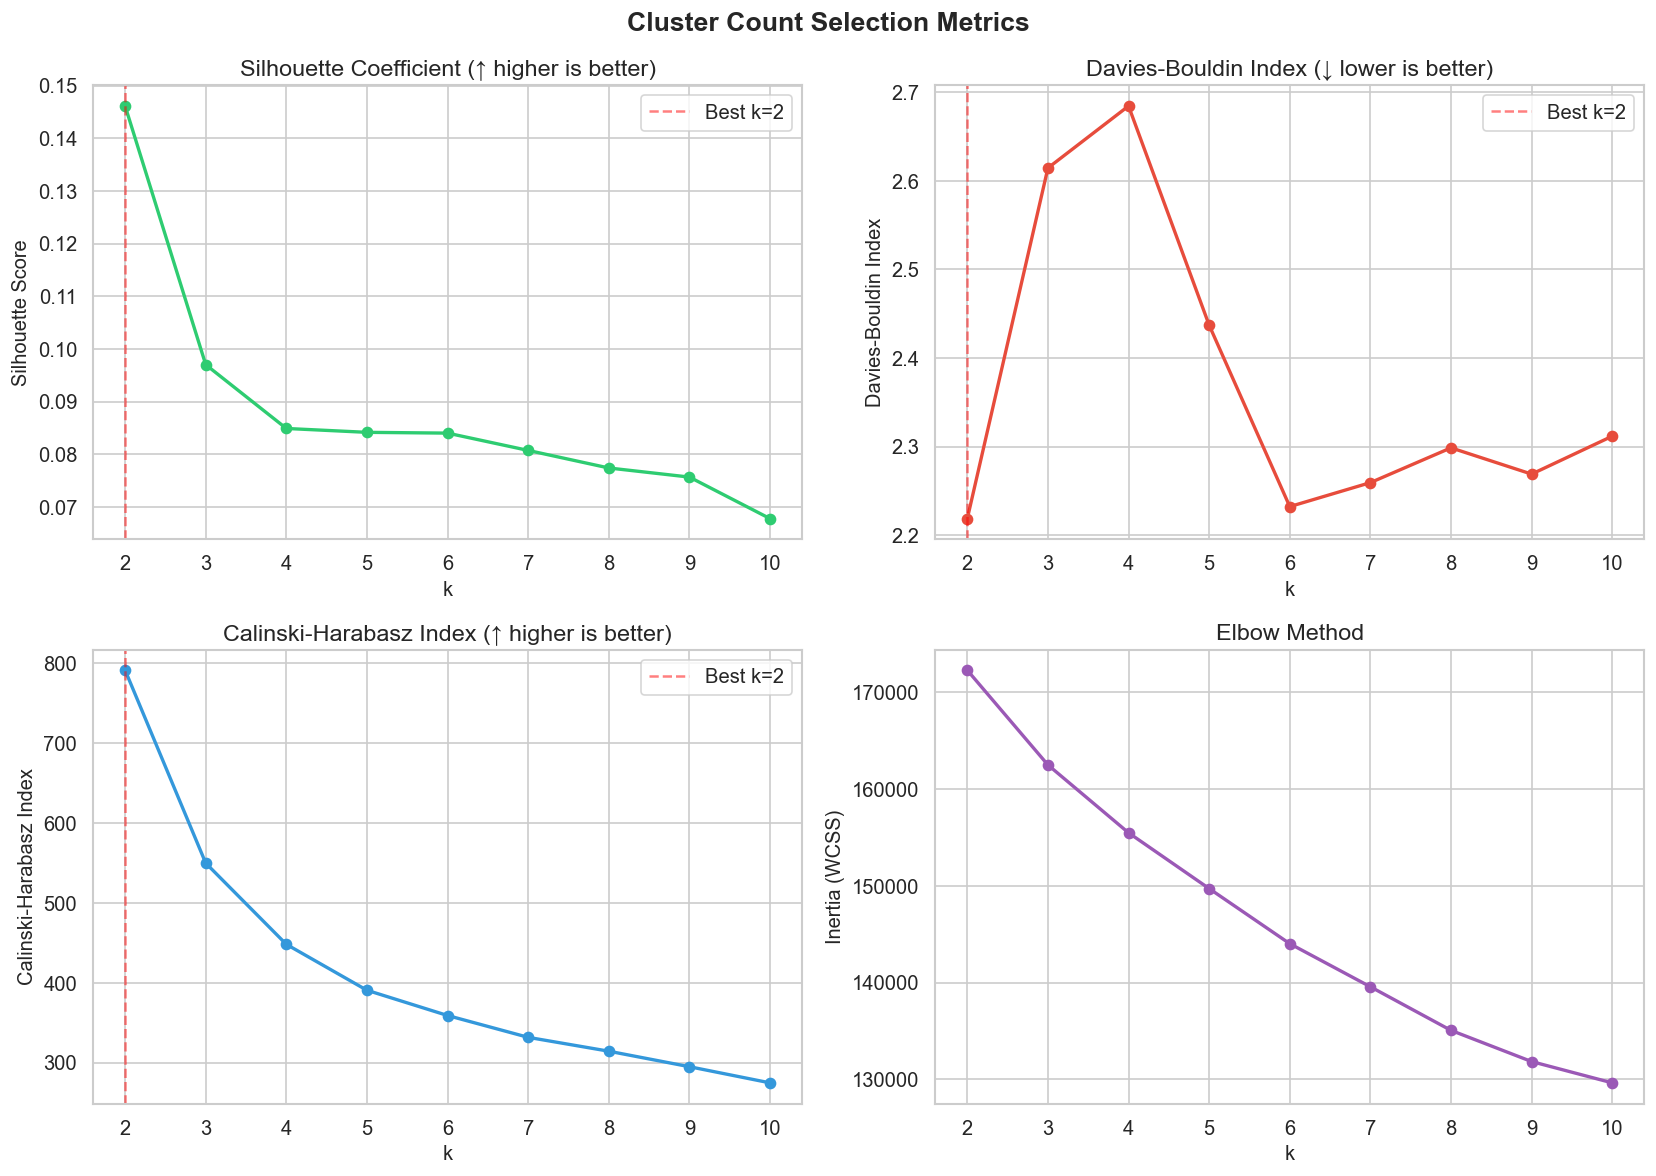


Selected k = 2 (highest Silhouette score)
Silhouette: 0.1461
Davies-Bouldin: 2.2187
Calinski-Harabasz: 791.1


In [5]:
K_RANGE = range(2, 11)

results = {'k': [], 'silhouette': [], 'davies_bouldin': [],
           'calinski_harabasz': [], 'inertia': []}

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X)
    results['k'].append(k)
    results['silhouette'].append(silhouette_score(X, labels))
    results['davies_bouldin'].append(davies_bouldin_score(X, labels))
    results['calinski_harabasz'].append(calinski_harabasz_score(X, labels))
    results['inertia'].append(km.inertia_)
    print(f"  k={k}: Silhouette={results['silhouette'][-1]:.4f}  DB={results['davies_bouldin'][-1]:.4f}  CH={results['calinski_harabasz'][-1]:.1f}")

res_df = pd.DataFrame(results)

# ── Plot ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Cluster Count Selection Metrics", fontsize=16, fontweight='bold')

ax = axes[0, 0]
ax.plot(res_df['k'], res_df['silhouette'], 'o-', color='#2ecc71', linewidth=2)
ax.set_xlabel('k'); ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Coefficient (↑ higher is better)')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
best_sil_k = res_df.loc[res_df['silhouette'].idxmax(), 'k']
ax.axvline(best_sil_k, color='red', linestyle='--', alpha=0.5, label=f'Best k={best_sil_k}')
ax.legend()

ax = axes[0, 1]
ax.plot(res_df['k'], res_df['davies_bouldin'], 'o-', color='#e74c3c', linewidth=2)
ax.set_xlabel('k'); ax.set_ylabel('Davies-Bouldin Index')
ax.set_title('Davies-Bouldin Index (↓ lower is better)')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
best_db_k = res_df.loc[res_df['davies_bouldin'].idxmin(), 'k']
ax.axvline(best_db_k, color='red', linestyle='--', alpha=0.5, label=f'Best k={best_db_k}')
ax.legend()

ax = axes[1, 0]
ax.plot(res_df['k'], res_df['calinski_harabasz'], 'o-', color='#3498db', linewidth=2)
ax.set_xlabel('k'); ax.set_ylabel('Calinski-Harabasz Index')
ax.set_title('Calinski-Harabasz Index (↑ higher is better)')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
best_ch_k = res_df.loc[res_df['calinski_harabasz'].idxmax(), 'k']
ax.axvline(best_ch_k, color='red', linestyle='--', alpha=0.5, label=f'Best k={best_ch_k}')
ax.legend()

ax = axes[1, 1]
ax.plot(res_df['k'], res_df['inertia'], 'o-', color='#9b59b6', linewidth=2)
ax.set_xlabel('k'); ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Elbow Method')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('cluster_selection_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# Choose best k
best_k = int(best_sil_k)
print(f"\n{'='*50}")
print(f"Selected k = {best_k} (highest Silhouette score)")
print(f"Silhouette: {res_df[res_df['k']==best_k]['silhouette'].values[0]:.4f}")
print(f"Davies-Bouldin: {res_df[res_df['k']==best_k]['davies_bouldin'].values[0]:.4f}")
print(f"Calinski-Harabasz: {res_df[res_df['k']==best_k]['calinski_harabasz'].values[0]:.1f}")


## 5. Permutation Test — Are Clusters Real?

This is the most critical statistical test. We compare the observed clustering
quality to a null distribution generated by shuffling the data, breaking
temporal and feature correlations. If our observed Silhouette score is
significantly higher than the null distribution, the clusters reflect **real
structure** rather than noise (adapted from Maris & Oostenveld, 2007).


Running 500 permutations (this may take a few minutes)...


  100/500 done...


  200/500 done...


  300/500 done...


  400/500 done...


  500/500 done...

Observed Silhouette Score: 0.1461
Null distribution mean:   0.0391 ± 0.1101
p-value:                  0.0360
Result: SIGNIFICANT (p < 0.05)


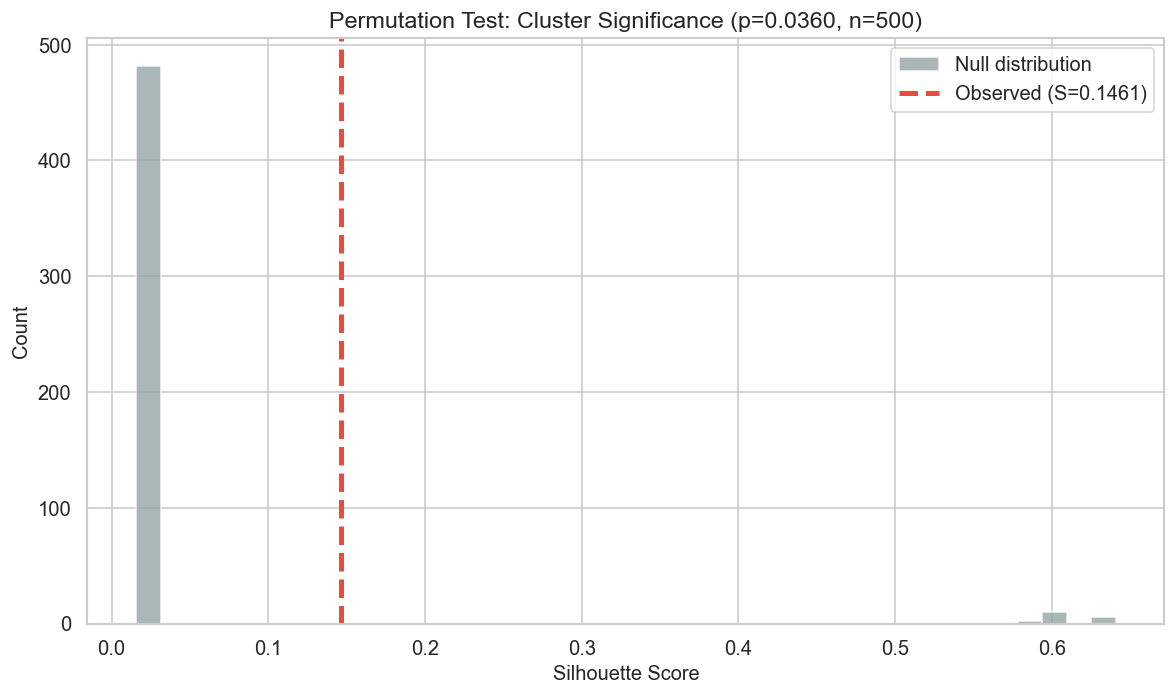

In [6]:
N_PERMUTATIONS = 500

km_obs = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_obs = km_obs.fit_predict(X)
s_obs = silhouette_score(X, labels_obs)

rng = np.random.RandomState(42)
s_null = np.zeros(N_PERMUTATIONS)

print(f"Running {N_PERMUTATIONS} permutations (this may take a few minutes)...")
for i in range(N_PERMUTATIONS):
    X_perm = X.copy()
    for col_idx in range(X_perm.shape[1]):
        rng.shuffle(X_perm[:, col_idx])
    labels_perm = KMeans(n_clusters=best_k, random_state=42, n_init=5).fit_predict(X_perm)
    s_null[i] = silhouette_score(X_perm, labels_perm)
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{N_PERMUTATIONS} done...")

p_value = np.mean(s_null >= s_obs)

print(f"\n{'='*50}")
print(f"Observed Silhouette Score: {s_obs:.4f}")
print(f"Null distribution mean:   {s_null.mean():.4f} ± {s_null.std():.4f}")
print(f"p-value:                  {p_value:.4f}")
if p_value < 0.001:
    print(f"Result: HIGHLY SIGNIFICANT (p < 0.001)")
    print(f"The discovered clusters represent REAL structure, not random noise.")
elif p_value < 0.05:
    print(f"Result: SIGNIFICANT (p < 0.05)")
else:
    print(f"Result: NOT significant (p >= 0.05)")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(s_null, bins=40, color='#95a5a6', edgecolor='white', alpha=0.8, label='Null distribution')
ax.axvline(s_obs, color='#e74c3c', linewidth=3, linestyle='--',
           label=f'Observed (S={s_obs:.4f})')
ax.set_xlabel('Silhouette Score')
ax.set_ylabel('Count')
ax.set_title(f'Permutation Test: Cluster Significance (p={p_value:.4f}, n={N_PERMUTATIONS})')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('permutation_test.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Bootstrap Stability Analysis

If the same clusters consistently appear in different random subsamples of the
data, they are **stable** (not an artifact of sample selection). We use the
Adjusted Rand Index (ARI) to measure agreement between clusterings of
different subsamples.


Bootstrap Stability Analysis (100 iterations, 80% subsamples)
Mean ARI: 0.9808 ± 0.0104
Median ARI: 0.9828
Min ARI: 0.9488

Interpretation: HIGHLY STABLE clusters


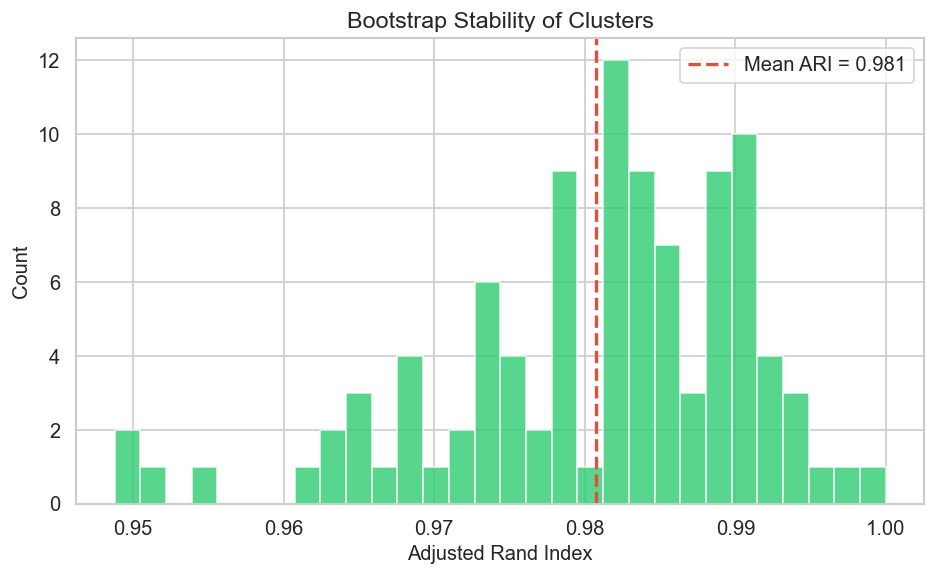

In [7]:
N_BOOTSTRAP = 100
SUBSAMPLE_FRAC = 0.8

ari_scores = []
rng = np.random.RandomState(123)

for i in range(N_BOOTSTRAP):
    n = X.shape[0]
    idx_a = rng.choice(n, size=int(n * SUBSAMPLE_FRAC), replace=False)
    idx_b = rng.choice(n, size=int(n * SUBSAMPLE_FRAC), replace=False)
    
    overlap = np.intersect1d(idx_a, idx_b)
    if len(overlap) < best_k * 2:
        continue
    
    labels_a = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X[idx_a])
    labels_b = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X[idx_b])
    
    # Map idx_a/idx_b labels to overlapping indices
    pos_a = {v: i for i, v in enumerate(idx_a)}
    pos_b = {v: i for i, v in enumerate(idx_b)}
    
    la = np.array([labels_a[pos_a[o]] for o in overlap])
    lb = np.array([labels_b[pos_b[o]] for o in overlap])
    
    ari_scores.append(adjusted_rand_score(la, lb))

ari_scores = np.array(ari_scores)

print(f"Bootstrap Stability Analysis ({N_BOOTSTRAP} iterations, {SUBSAMPLE_FRAC*100:.0f}% subsamples)")
print(f"{'='*50}")
print(f"Mean ARI: {ari_scores.mean():.4f} ± {ari_scores.std():.4f}")
print(f"Median ARI: {np.median(ari_scores):.4f}")
print(f"Min ARI: {ari_scores.min():.4f}")
print()
if ari_scores.mean() > 0.8:
    print("Interpretation: HIGHLY STABLE clusters")
elif ari_scores.mean() > 0.5:
    print("Interpretation: MODERATELY STABLE clusters")
else:
    print("Interpretation: WEAKLY STABLE clusters — interpret with caution")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ari_scores, bins=30, color='#2ecc71', edgecolor='white', alpha=0.8)
ax.axvline(ari_scores.mean(), color='#e74c3c', linewidth=2, linestyle='--',
           label=f'Mean ARI = {ari_scores.mean():.3f}')
ax.set_xlabel('Adjusted Rand Index')
ax.set_ylabel('Count')
ax.set_title('Bootstrap Stability of Clusters')
ax.legend()
plt.tight_layout()
plt.savefig('bootstrap_stability.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Final Clustering & Visualization


PCA explained variance: PC1=22.9%, PC2=10.4%, PC3=7.3%
Total (3 components): 40.6%


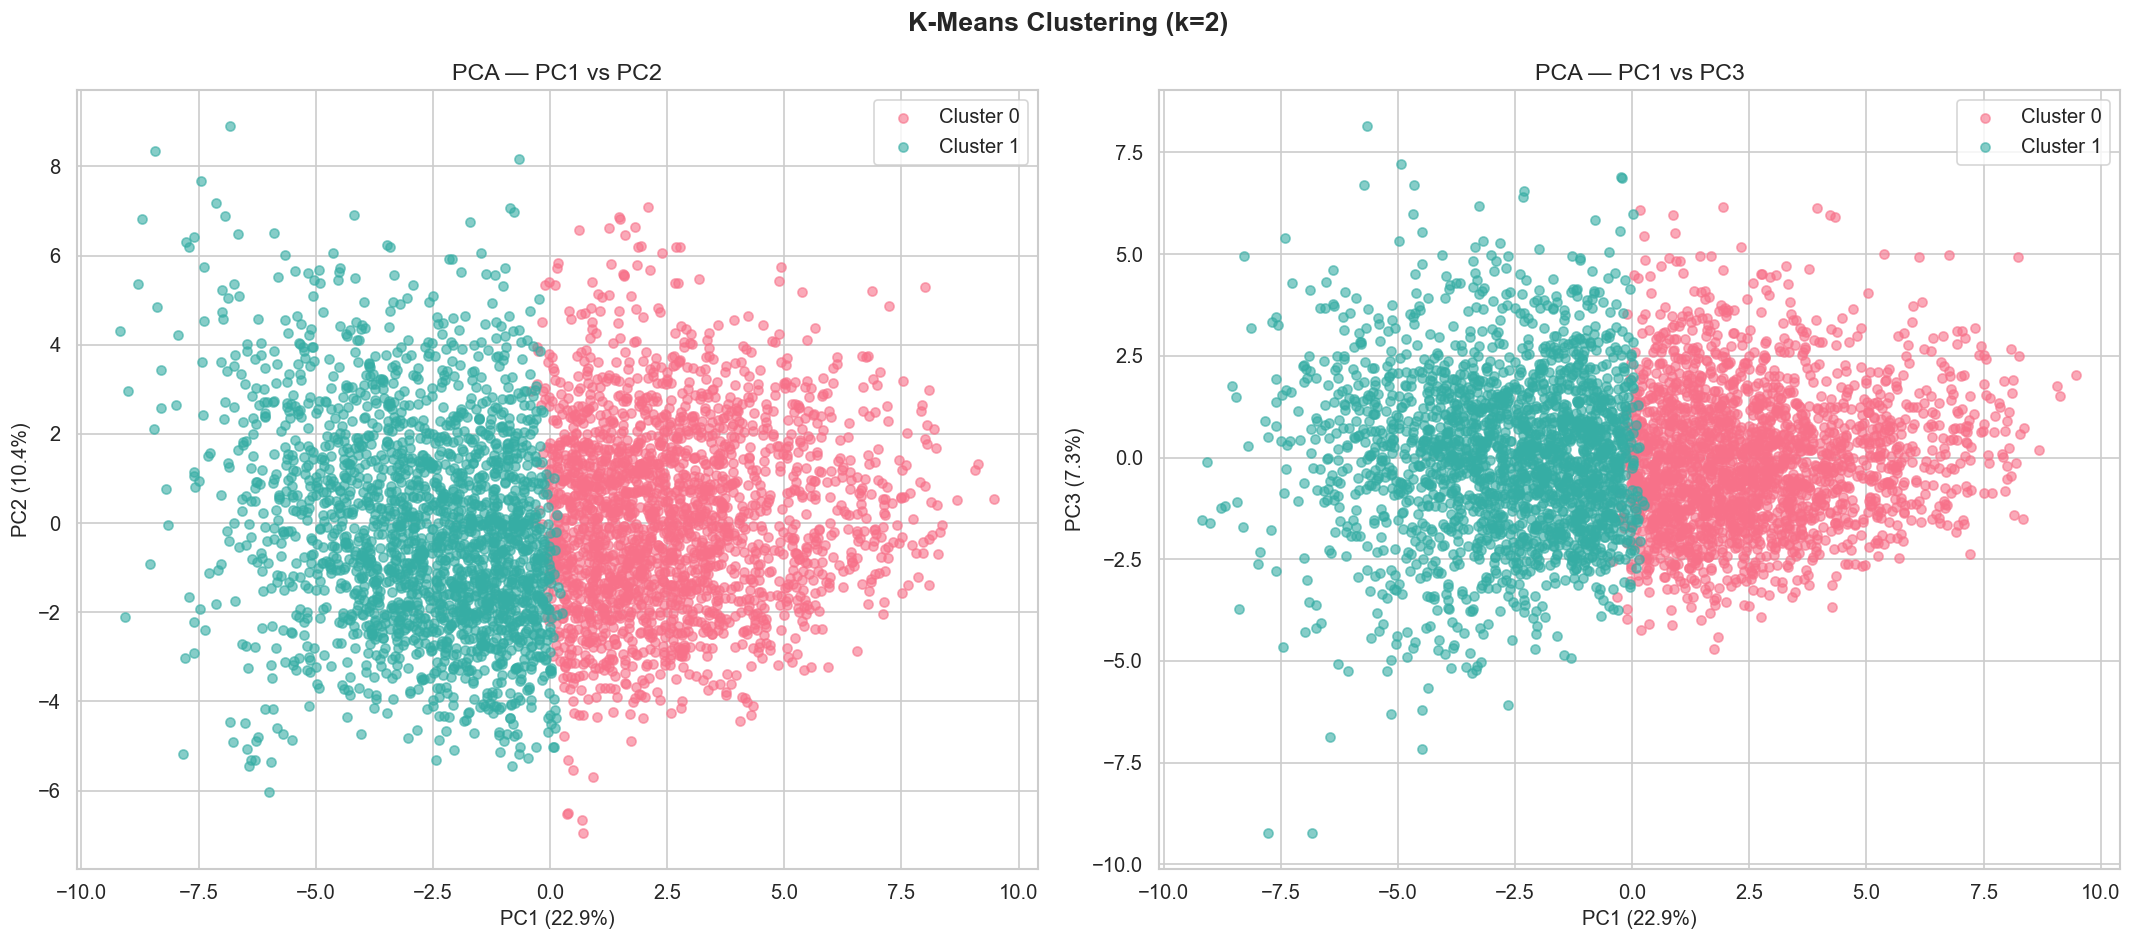

In [8]:
# Final K-Means
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
window_clean['cluster'] = km_final.fit_predict(X)

# PCA for visualization
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
window_clean['pca1'] = X_pca[:, 0]
window_clean['pca2'] = X_pca[:, 1]
window_clean['pca3'] = X_pca[:, 2]

evr = pca.explained_variance_ratio_
print(f"PCA explained variance: PC1={evr[0]:.1%}, PC2={evr[1]:.1%}, PC3={evr[2]:.1%}")
print(f"Total (3 components): {sum(evr):.1%}")

# ── Scatter plot ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

palette = sns.color_palette("husl", best_k)
for i in range(best_k):
    mask = window_clean['cluster'] == i
    axes[0].scatter(window_clean.loc[mask, 'pca1'], window_clean.loc[mask, 'pca2'],
                    s=30, alpha=0.6, color=palette[i], label=f'Cluster {i}')
    axes[1].scatter(window_clean.loc[mask, 'pca1'], window_clean.loc[mask, 'pca3'],
                    s=30, alpha=0.6, color=palette[i], label=f'Cluster {i}')

axes[0].set_xlabel(f'PC1 ({evr[0]:.1%})'); axes[0].set_ylabel(f'PC2 ({evr[1]:.1%})')
axes[0].set_title('PCA — PC1 vs PC2'); axes[0].legend()
axes[1].set_xlabel(f'PC1 ({evr[0]:.1%})'); axes[1].set_ylabel(f'PC3 ({evr[2]:.1%})')
axes[1].set_title('PCA — PC1 vs PC3'); axes[1].legend()

plt.suptitle(f'K-Means Clustering (k={best_k})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Cluster Profiling — What Does Each Cluster Mean?

We compute the mean feature value per cluster and visualize as a heatmap.
Features are normalized 0–1 for visual comparison.


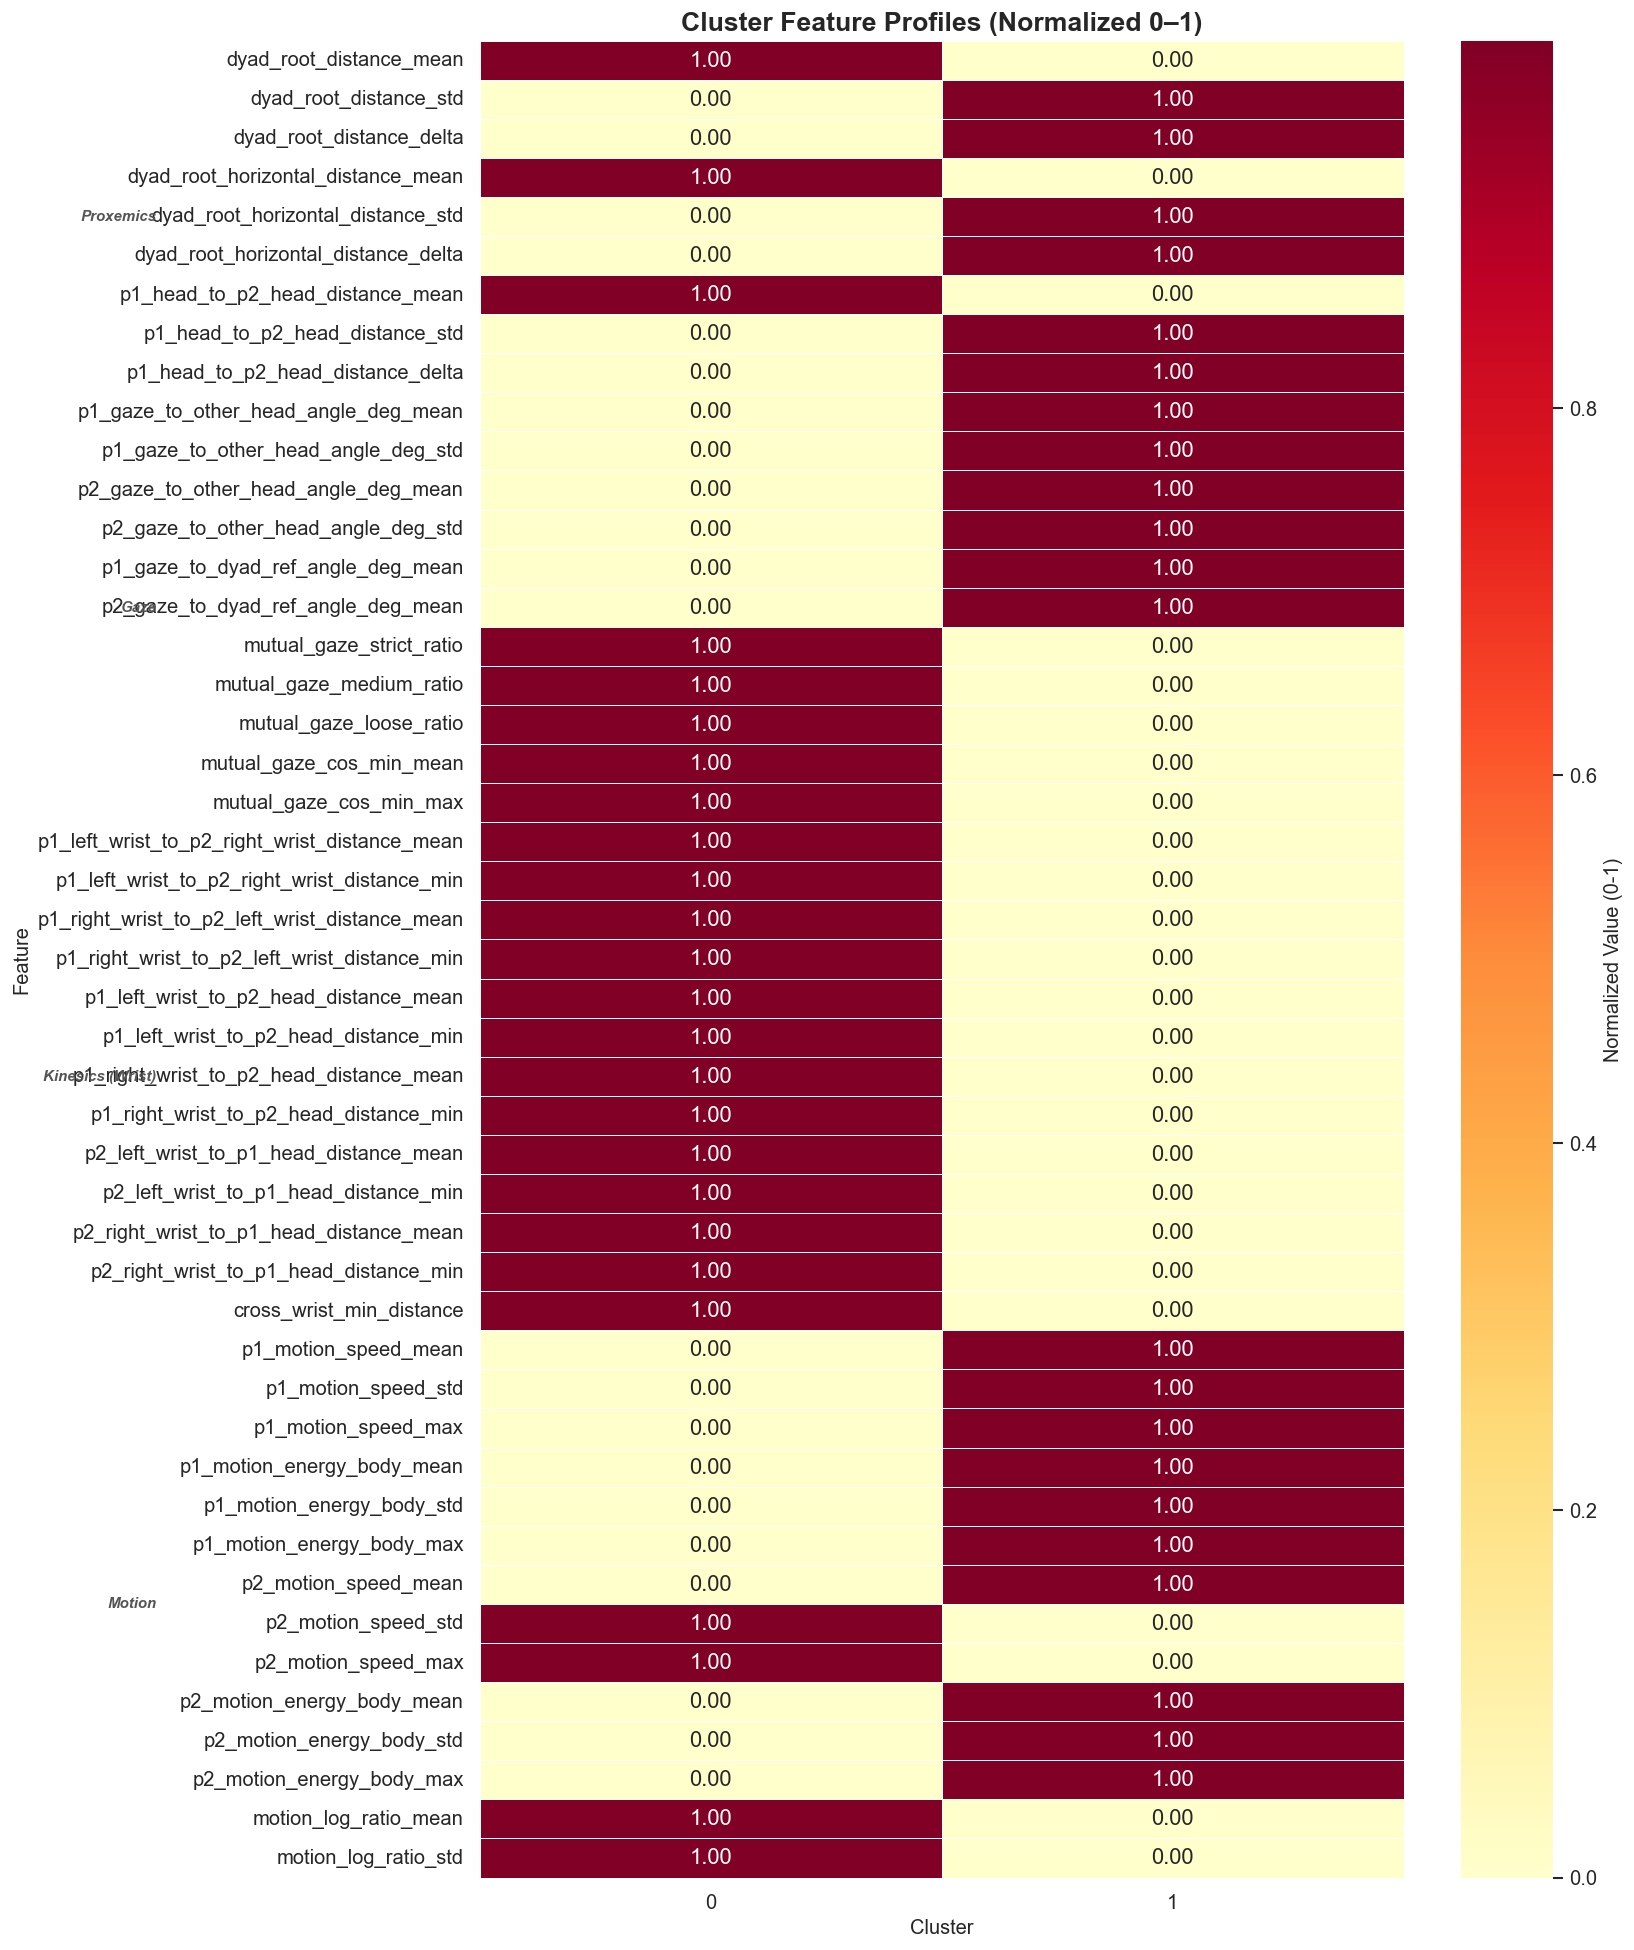


Raw Cluster Means:


cluster,0,1
dyad_root_distance_mean,0.9381,0.7277
dyad_root_distance_std,0.0458,0.0599
dyad_root_distance_delta,-0.0032,0.0021
dyad_root_horizontal_distance_mean,0.9331,0.7221
dyad_root_horizontal_distance_std,0.0461,0.0597
dyad_root_horizontal_distance_delta,-0.0032,0.0020
p1_head_to_p2_head_distance_mean,0.7212,0.5330
p1_head_to_p2_head_distance_std,0.0272,0.0499
p1_head_to_p2_head_distance_delta,-0.0004,0.0016
p1_gaze_to_other_head_angle_deg_mean,28.1698,30.8982


In [9]:
profile_cols = [c for c in feature_cols if c in window_clean.columns]
profiles = window_clean.groupby('cluster')[profile_cols].mean()

# Normalize 0-1 for heatmap
profiles_norm = (profiles - profiles.min()) / (profiles.max() - profiles.min() + 1e-9)

# Reorder features by category for readability
cat_order = []
cats = {
    'Proxemics': [c for c in profile_cols if 'dyad_root' in c or 'head_to_p2_head' in c],
    'Gaze': [c for c in profile_cols if 'gaze' in c or 'mutual' in c],
    'Kinesics (Wrist)': [c for c in profile_cols if 'wrist' in c],
    'Motion': [c for c in profile_cols if 'motion' in c],
}
for cat_name, cat_cols in cats.items():
    cat_order.extend([c for c in cat_cols if c in profiles_norm.columns])
# Add any remaining
remaining = [c for c in profiles_norm.columns if c not in cat_order]
cat_order.extend(remaining)

profiles_norm = profiles_norm[cat_order]

fig, ax = plt.subplots(figsize=(14, max(10, len(cat_order) * 0.35)))
sns.heatmap(profiles_norm.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized Value (0-1)'})
ax.set_title('Cluster Feature Profiles (Normalized 0–1)', fontsize=16, fontweight='bold')
ax.set_ylabel('Feature')
ax.set_xlabel('Cluster')

# Add category separators
prev_end = 0
for cat_name, cat_cols in cats.items():
    n_in = len([c for c in cat_cols if c in profiles_norm.columns])
    if n_in > 0:
        mid = prev_end + n_in / 2
        ax.text(-0.7, mid, cat_name, ha='right', va='center', fontsize=9, fontweight='bold',
                rotation=0, style='italic', color='#555')
        prev_end += n_in

plt.tight_layout()
plt.savefig('cluster_profiles_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Also print raw means
print("\nRaw Cluster Means:")
profiles.T.round(4)


## 9. Per-Cluster Silhouette Analysis

Shows how well-defined each individual cluster is.


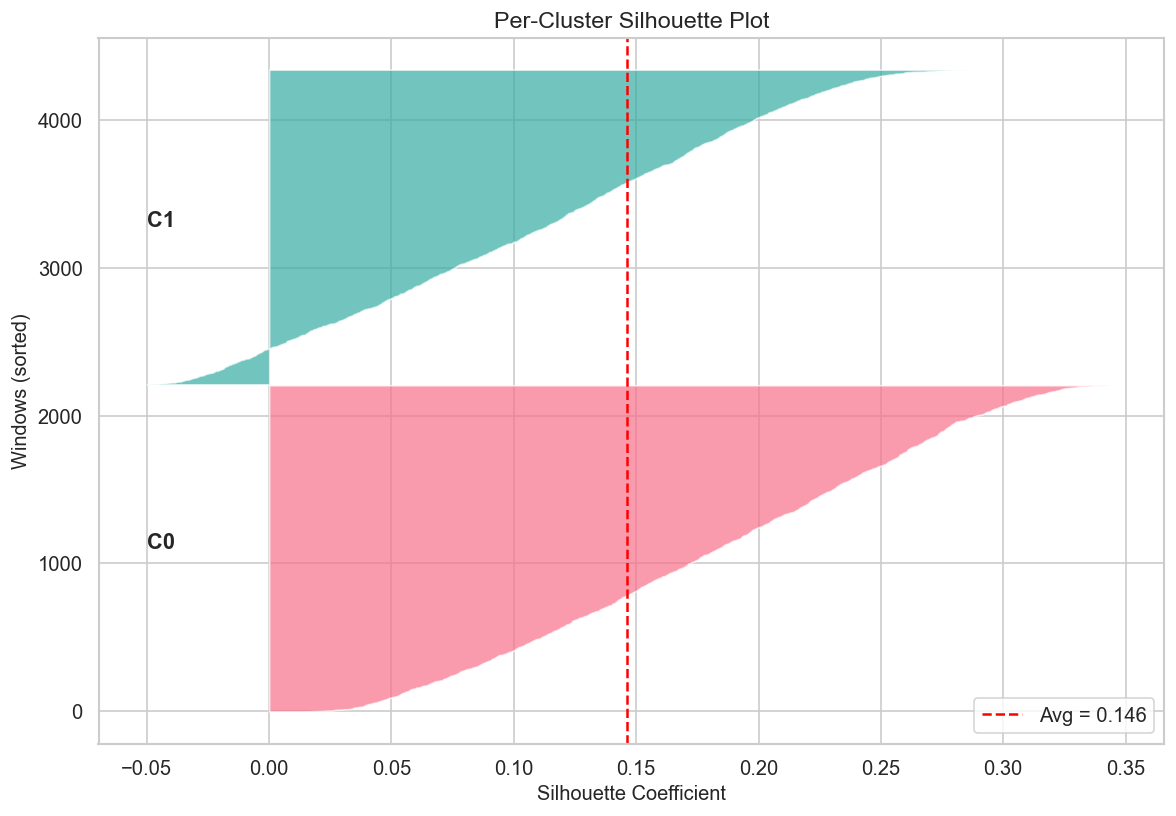

Cluster 0: n= 2206, mean_sil=0.182, neg_ratio=0.0%
Cluster 1: n= 2129, mean_sil=0.109, neg_ratio=11.4%


In [10]:
sample_silhouettes = silhouette_samples(X, window_clean['cluster'].values)
window_clean['silhouette'] = sample_silhouettes

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 0
for i in range(best_k):
    cluster_sil = np.sort(sample_silhouettes[window_clean['cluster'].values == i])
    size_i = cluster_sil.shape[0]
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=palette[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_i, f'C{i}', fontweight='bold')
    y_lower = y_upper + 5

ax.axvline(silhouette_score(X, window_clean['cluster'].values),
           color='red', linestyle='--', label=f'Avg = {s_obs:.3f}')
ax.set_xlabel('Silhouette Coefficient'); ax.set_ylabel('Windows (sorted)')
ax.set_title('Per-Cluster Silhouette Plot')
ax.legend()
plt.tight_layout()
plt.savefig('silhouette_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-cluster stats
for i in range(best_k):
    mask = window_clean['cluster'] == i
    sils = sample_silhouettes[mask]
    print(f"Cluster {i}: n={mask.sum():>5}, mean_sil={sils.mean():.3f}, "
          f"neg_ratio={100*(sils<0).mean():.1f}%")


## 10. Markov Transition Analysis

If the interaction states (clusters) follow a structured temporal sequence
rather than random jumps, this is strong evidence of **intentional non-verbal
communication** (Sacks, Schegloff & Jefferson, 1974).

We compute:
1. **Transition matrix** (empirical probabilities)
2. **Chi-squared test** against uniform transitions
3. **Transition entropy** (lower = more predictable)


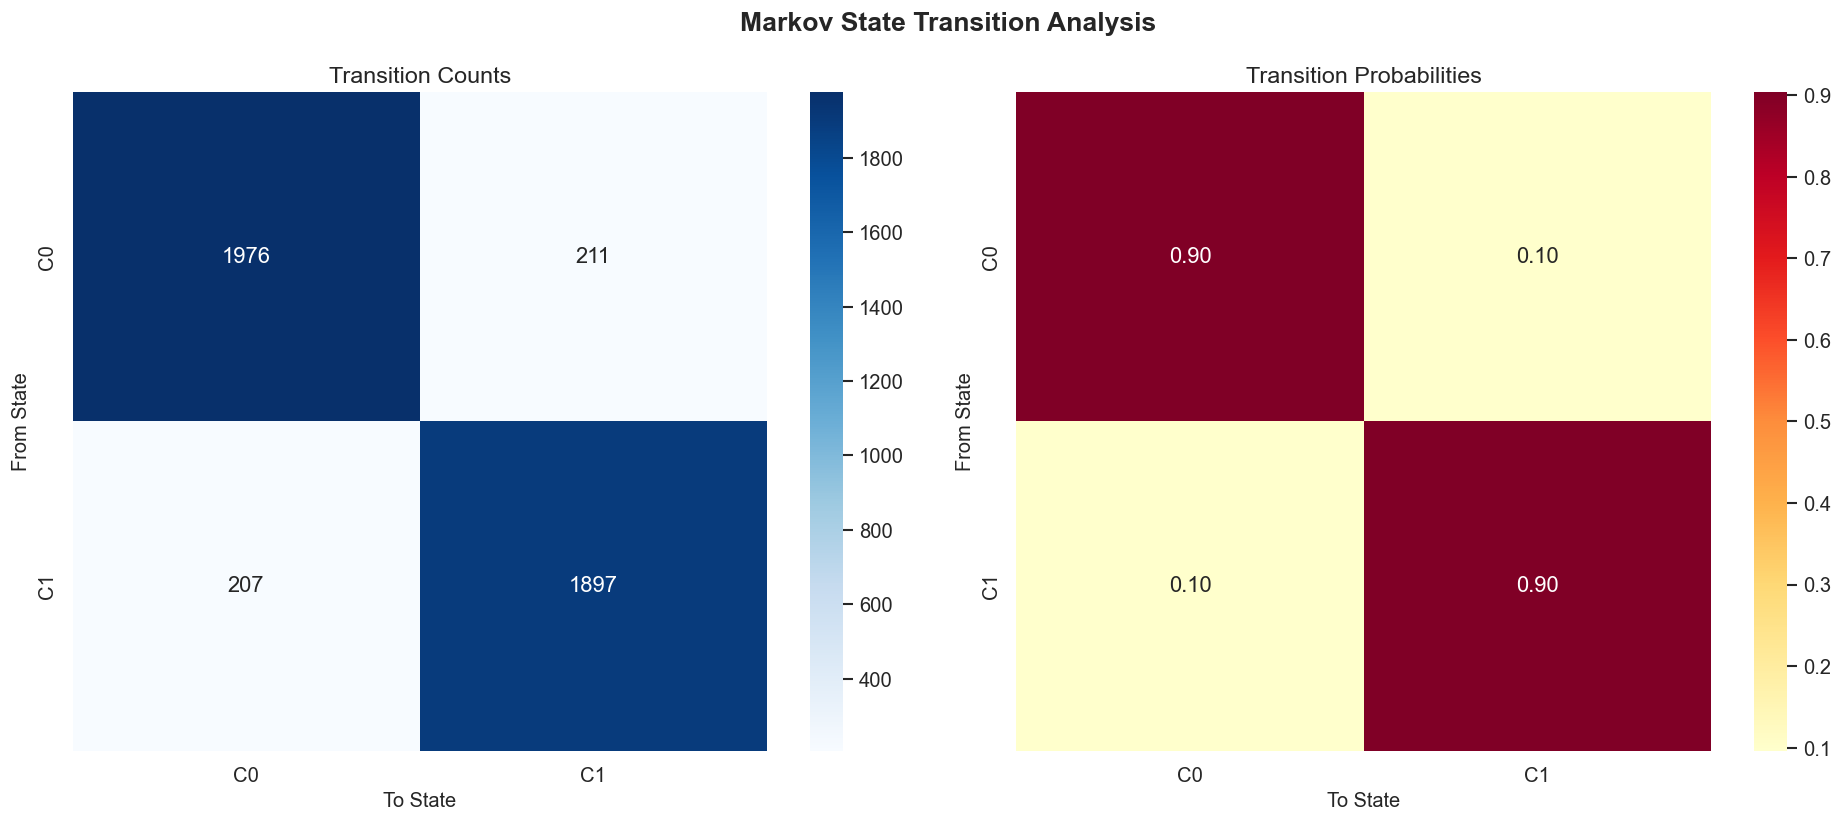


Chi-Squared Test: Are transitions non-uniform?
  From C0: χ²= 1424.43, p=0.000000 ***
  From C1: χ²= 1357.46, p=0.000000 ***

Transition Entropy (lower = more predictable)
  C0: H=0.458 / 1.000  [█████████████░░░░░░░░░░░░░░░░░]  (45.8% of max)
  C1: H=0.464 / 1.000  [█████████████░░░░░░░░░░░░░░░░░]  (46.4% of max)


In [11]:
# Build per-session transition sequences
transitions = np.zeros((best_k, best_k), dtype=int)

for session_name, group in window_clean.groupby('session_label'):
    group_sorted = group.sort_values('window_start_frame')
    labels = group_sorted['cluster'].values
    for j in range(len(labels) - 1):
        transitions[labels[j], labels[j + 1]] += 1

# Normalize to probabilities
row_sums = transitions.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
T = transitions / row_sums

# ── Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Raw counts
sns.heatmap(transitions, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'C{i}' for i in range(best_k)],
            yticklabels=[f'C{i}' for i in range(best_k)])
axes[0].set_title('Transition Counts')
axes[0].set_xlabel('To State'); axes[0].set_ylabel('From State')

# Probabilities
sns.heatmap(T, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            xticklabels=[f'C{i}' for i in range(best_k)],
            yticklabels=[f'C{i}' for i in range(best_k)])
axes[1].set_title('Transition Probabilities')
axes[1].set_xlabel('To State'); axes[1].set_ylabel('From State')

plt.suptitle('Markov State Transition Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('transition_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Chi-squared test against uniform ──
print("\n" + "="*60)
print("Chi-Squared Test: Are transitions non-uniform?")
print("="*60)
for i in range(best_k):
    observed = transitions[i]
    if observed.sum() == 0:
        continue
    expected = np.full(best_k, observed.sum() / best_k)
    chi2, p = stats.chisquare(observed, expected)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    print(f"  From C{i}: χ²={chi2:8.2f}, p={p:.6f} {sig}")

# ── Entropy analysis ──
print(f"\n{'='*60}")
print("Transition Entropy (lower = more predictable)")
print("="*60)
max_entropy = np.log2(best_k)
for i in range(best_k):
    row = T[i]
    row_nonzero = row[row > 0]
    entropy = -np.sum(row_nonzero * np.log2(row_nonzero))
    ratio = entropy / max_entropy
    bar = "█" * int(ratio * 30) + "░" * (30 - int(ratio * 30))
    print(f"  C{i}: H={entropy:.3f} / {max_entropy:.3f}  [{bar}]  ({ratio:.1%} of max)")


## 11. Cross-Session Consistency

If the same interaction patterns appear across **different dyads and sessions**,
they are genuine behavioral phenomena — not artifacts of a single session.


Cross-Session Consistency
  Cluster 0: appears in 39/44 sessions (89%)
  Cluster 1: appears in 44/44 sessions (100%)


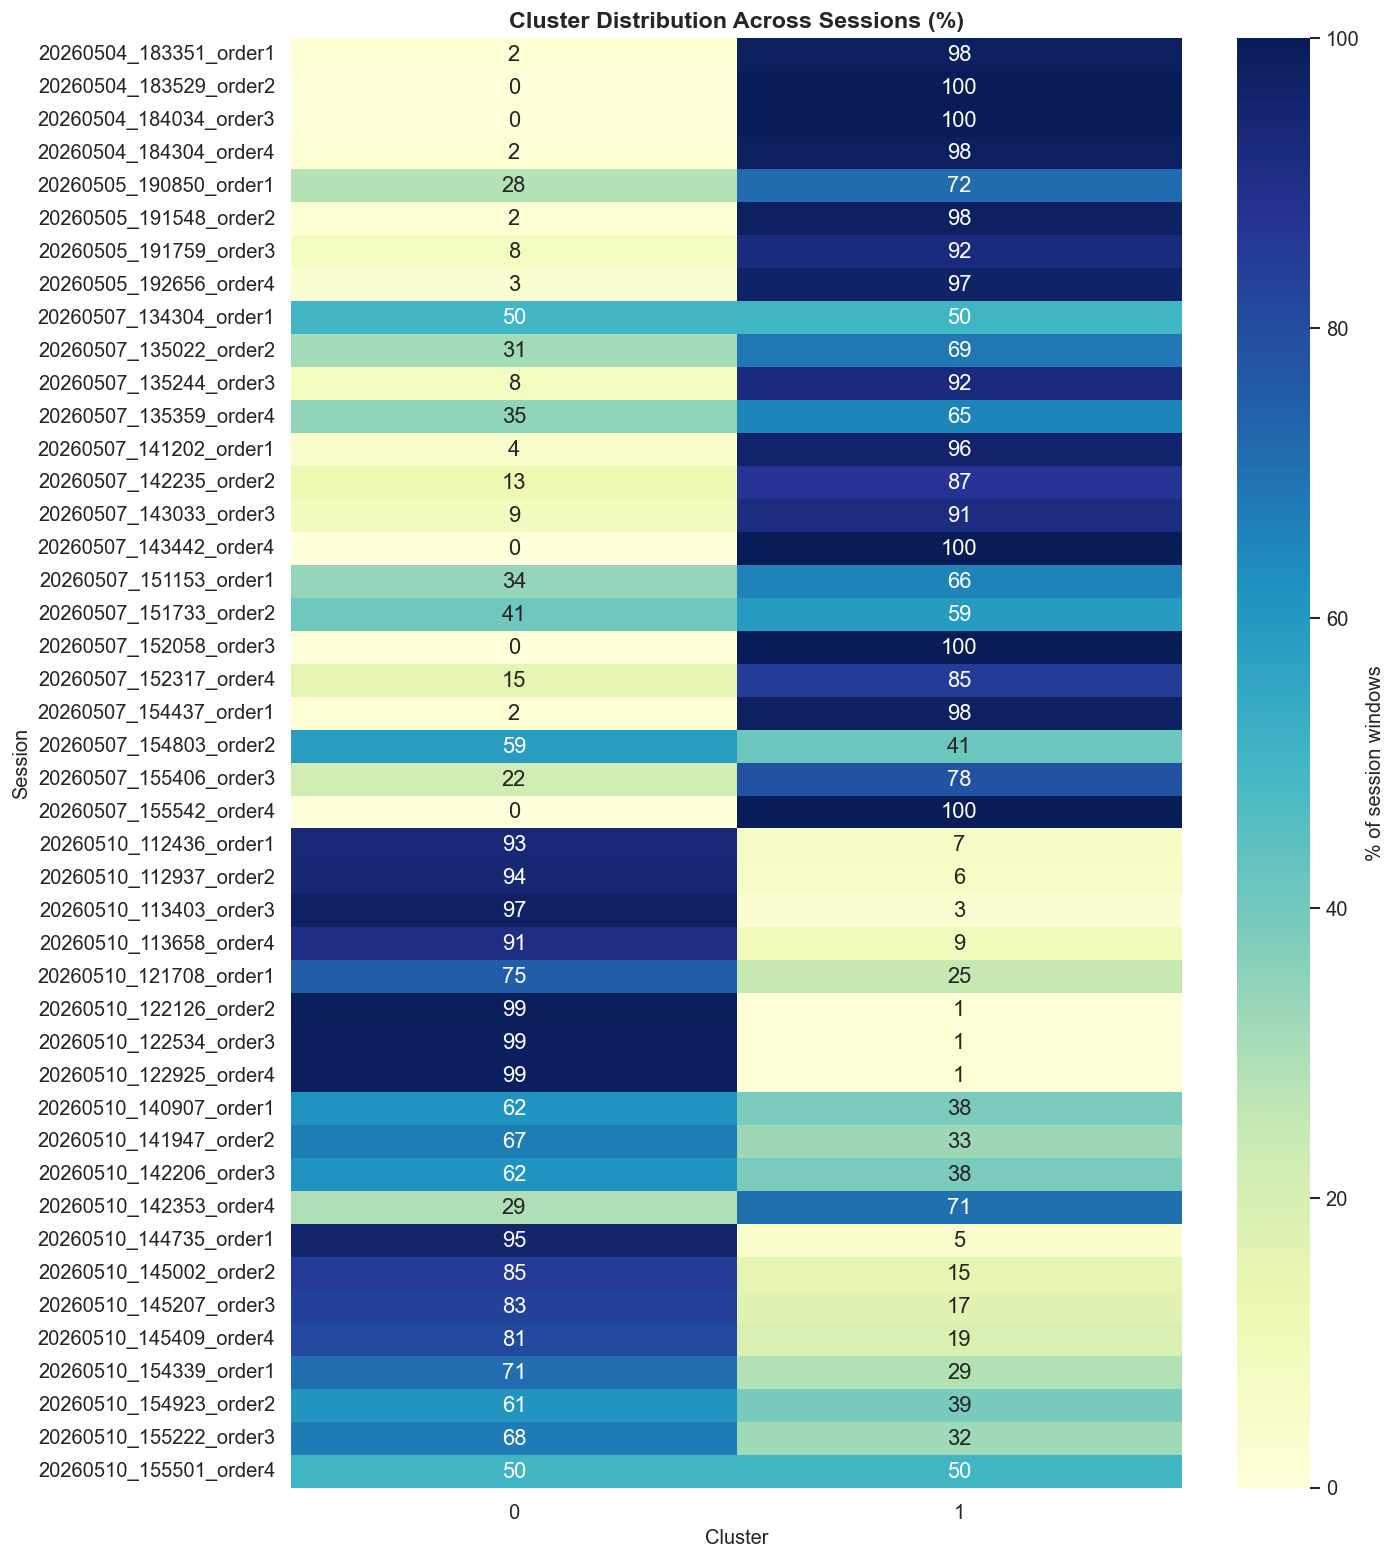


Cluster Prevalence Stability (lower CV = more consistent):
  Cluster 0: mean=43.8%, std=36.5%, CV=0.83
  Cluster 1: mean=56.2%, std=36.5%, CV=0.65


In [12]:
# Cluster distribution per session
session_cluster_counts = window_clean.groupby(['session_label', 'cluster']).size().unstack(fill_value=0)
session_cluster_pct = session_cluster_counts.div(session_cluster_counts.sum(axis=1), axis=0) * 100

# How many sessions contain each cluster?
print("Cross-Session Consistency")
print("="*60)
for i in range(best_k):
    n_sessions_with = (session_cluster_counts[i] > 0).sum()
    total_sessions = len(session_cluster_counts)
    pct = n_sessions_with / total_sessions * 100
    print(f"  Cluster {i}: appears in {n_sessions_with}/{total_sessions} sessions ({pct:.0f}%)")

# Heatmap of session × cluster distribution
fig, ax = plt.subplots(figsize=(12, max(8, len(session_cluster_pct) * 0.3)))
sns.heatmap(session_cluster_pct, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax,
            cbar_kws={'label': '% of session windows'})
ax.set_title('Cluster Distribution Across Sessions (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Session')
plt.tight_layout()
plt.savefig('cross_session_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

# Coefficient of Variation per cluster across sessions
print(f"\nCluster Prevalence Stability (lower CV = more consistent):")
for i in range(best_k):
    pcts = session_cluster_pct[i]
    cv = pcts.std() / (pcts.mean() + 1e-9)
    print(f"  Cluster {i}: mean={pcts.mean():.1f}%, std={pcts.std():.1f}%, CV={cv:.2f}")


## 12. Summary & Evidence Table

### Statistical Evidence Collected

| Test | Result | Interpretation |
|------|--------|---------------|
| **Silhouette Score** | See §4 | Cluster separability quality |
| **Permutation Test** | See §5 | Clusters are non-random (p-value) |
| **Bootstrap Stability** | See §6 | Clusters are reproducible (ARI) |
| **Chi-Squared Transitions** | See §10 | Transitions are non-uniform |
| **Cross-Session Consistency** | See §11 | Patterns generalize across dyads |

### Next Steps
1. Assign human-readable labels to clusters based on feature profiles
2. Investigate specific transition sequences (e.g., Planning → Action → Handover)
3. Compute interpersonal synchrony via cross-correlation of motion time-series
4. Consider AR-HMMs for future work (Wiltschko et al., 2015; Weinreb et al., 2024)


## 13. Hierarchical Vocabulary Discovery

### Why k=2 is not enough for vocabulary

The Silhouette metric favors k=2 (highest score: 0.146), giving the **cleanest binary
split**. However, a non-verbal communication "vocabulary" requires finer granularity.

Critically, the Silhouette scores plateau at k=4–6 (0.084–0.085), which suggests
**stable sub-structure** within the two macro-states.

### Approach (Hierarchical)

1. **Level 1 (k=2):** Macro interaction states — already validated (p=0.036, ARI=0.98)  
2. **Level 2 (k=5):** Micro behavioral vocabulary — to be validated below

This hierarchical framing is common in behavioral research (Wiltschko et al., 2015):
macro states capture high-level phases, while micro states capture the specific
non-verbal signals ("behavioral syllables").


In [13]:
# ═══════════════════════════════════════════════════════
# HIERARCHICAL ANALYSIS: k=5 for vocabulary discovery
# ═══════════════════════════════════════════════════════

VOCAB_K = 5

km_vocab = KMeans(n_clusters=VOCAB_K, random_state=42, n_init=10)
window_clean['vocab_cluster'] = km_vocab.fit_predict(X)

s_vocab = silhouette_score(X, window_clean['vocab_cluster'].values)
db_vocab = davies_bouldin_score(X, window_clean['vocab_cluster'].values)
ch_vocab = calinski_harabasz_score(X, window_clean['vocab_cluster'].values)

print(f"Vocabulary Clustering (k={VOCAB_K})")
print(f"{'='*50}")
print(f"Silhouette:       {s_vocab:.4f}")
print(f"Davies-Bouldin:   {db_vocab:.4f}")
print(f"Calinski-Harabasz: {ch_vocab:.1f}")


Vocabulary Clustering (k=5)
Silhouette:       0.0842
Davies-Bouldin:   2.4371
Calinski-Harabasz: 390.6


### 13.1 Permutation Test for k=5

Even though k=5 has a lower Silhouette than k=2, the clusters may still
represent **real structure** beyond noise. This permutation test proves it.


Running 500 permutations for k=5...


  100/500 done...


  200/500 done...


  300/500 done...


  400/500 done...


  500/500 done...

Observed Silhouette (k=5): 0.0842
Null mean: 0.0129 ± 0.0029
p-value: 0.0000
Result: HIGHLY SIGNIFICANT (p < 0.001) — vocabulary clusters are REAL


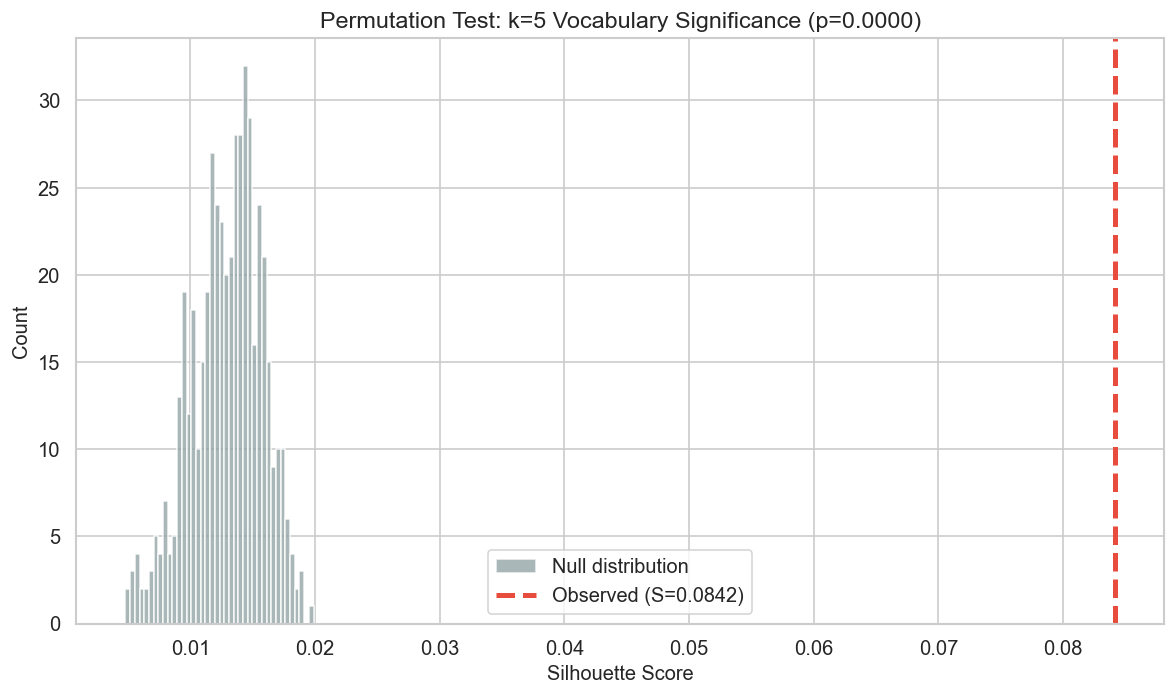

In [14]:
N_PERM_V = 500
rng_v = np.random.RandomState(99)
s_null_v = np.zeros(N_PERM_V)

print(f"Running {N_PERM_V} permutations for k={VOCAB_K}...")
for i in range(N_PERM_V):
    X_perm = X.copy()
    for col_idx in range(X_perm.shape[1]):
        rng_v.shuffle(X_perm[:, col_idx])
    labels_perm = KMeans(n_clusters=VOCAB_K, random_state=42, n_init=5).fit_predict(X_perm)
    s_null_v[i] = silhouette_score(X_perm, labels_perm)
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{N_PERM_V} done...")

p_value_v = np.mean(s_null_v >= s_vocab)

print(f"\n{'='*50}")
print(f"Observed Silhouette (k={VOCAB_K}): {s_vocab:.4f}")
print(f"Null mean: {s_null_v.mean():.4f} ± {s_null_v.std():.4f}")
print(f"p-value: {p_value_v:.4f}")
if p_value_v < 0.001:
    print("Result: HIGHLY SIGNIFICANT (p < 0.001) — vocabulary clusters are REAL")
elif p_value_v < 0.05:
    print("Result: SIGNIFICANT (p < 0.05) — vocabulary clusters are REAL")
else:
    print("Result: NOT significant — clusters may reflect noise")

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(s_null_v, bins=40, color='#95a5a6', edgecolor='white', alpha=0.8, label='Null distribution')
ax.axvline(s_vocab, color='#e74c3c', linewidth=3, linestyle='--',
           label=f'Observed (S={s_vocab:.4f})')
ax.set_xlabel('Silhouette Score')
ax.set_ylabel('Count')
ax.set_title(f'Permutation Test: k={VOCAB_K} Vocabulary Significance (p={p_value_v:.4f})')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('permutation_test_k5.png', dpi=150, bbox_inches='tight')
plt.show()


### 13.2 Vocabulary Cluster Profiles (k=5)


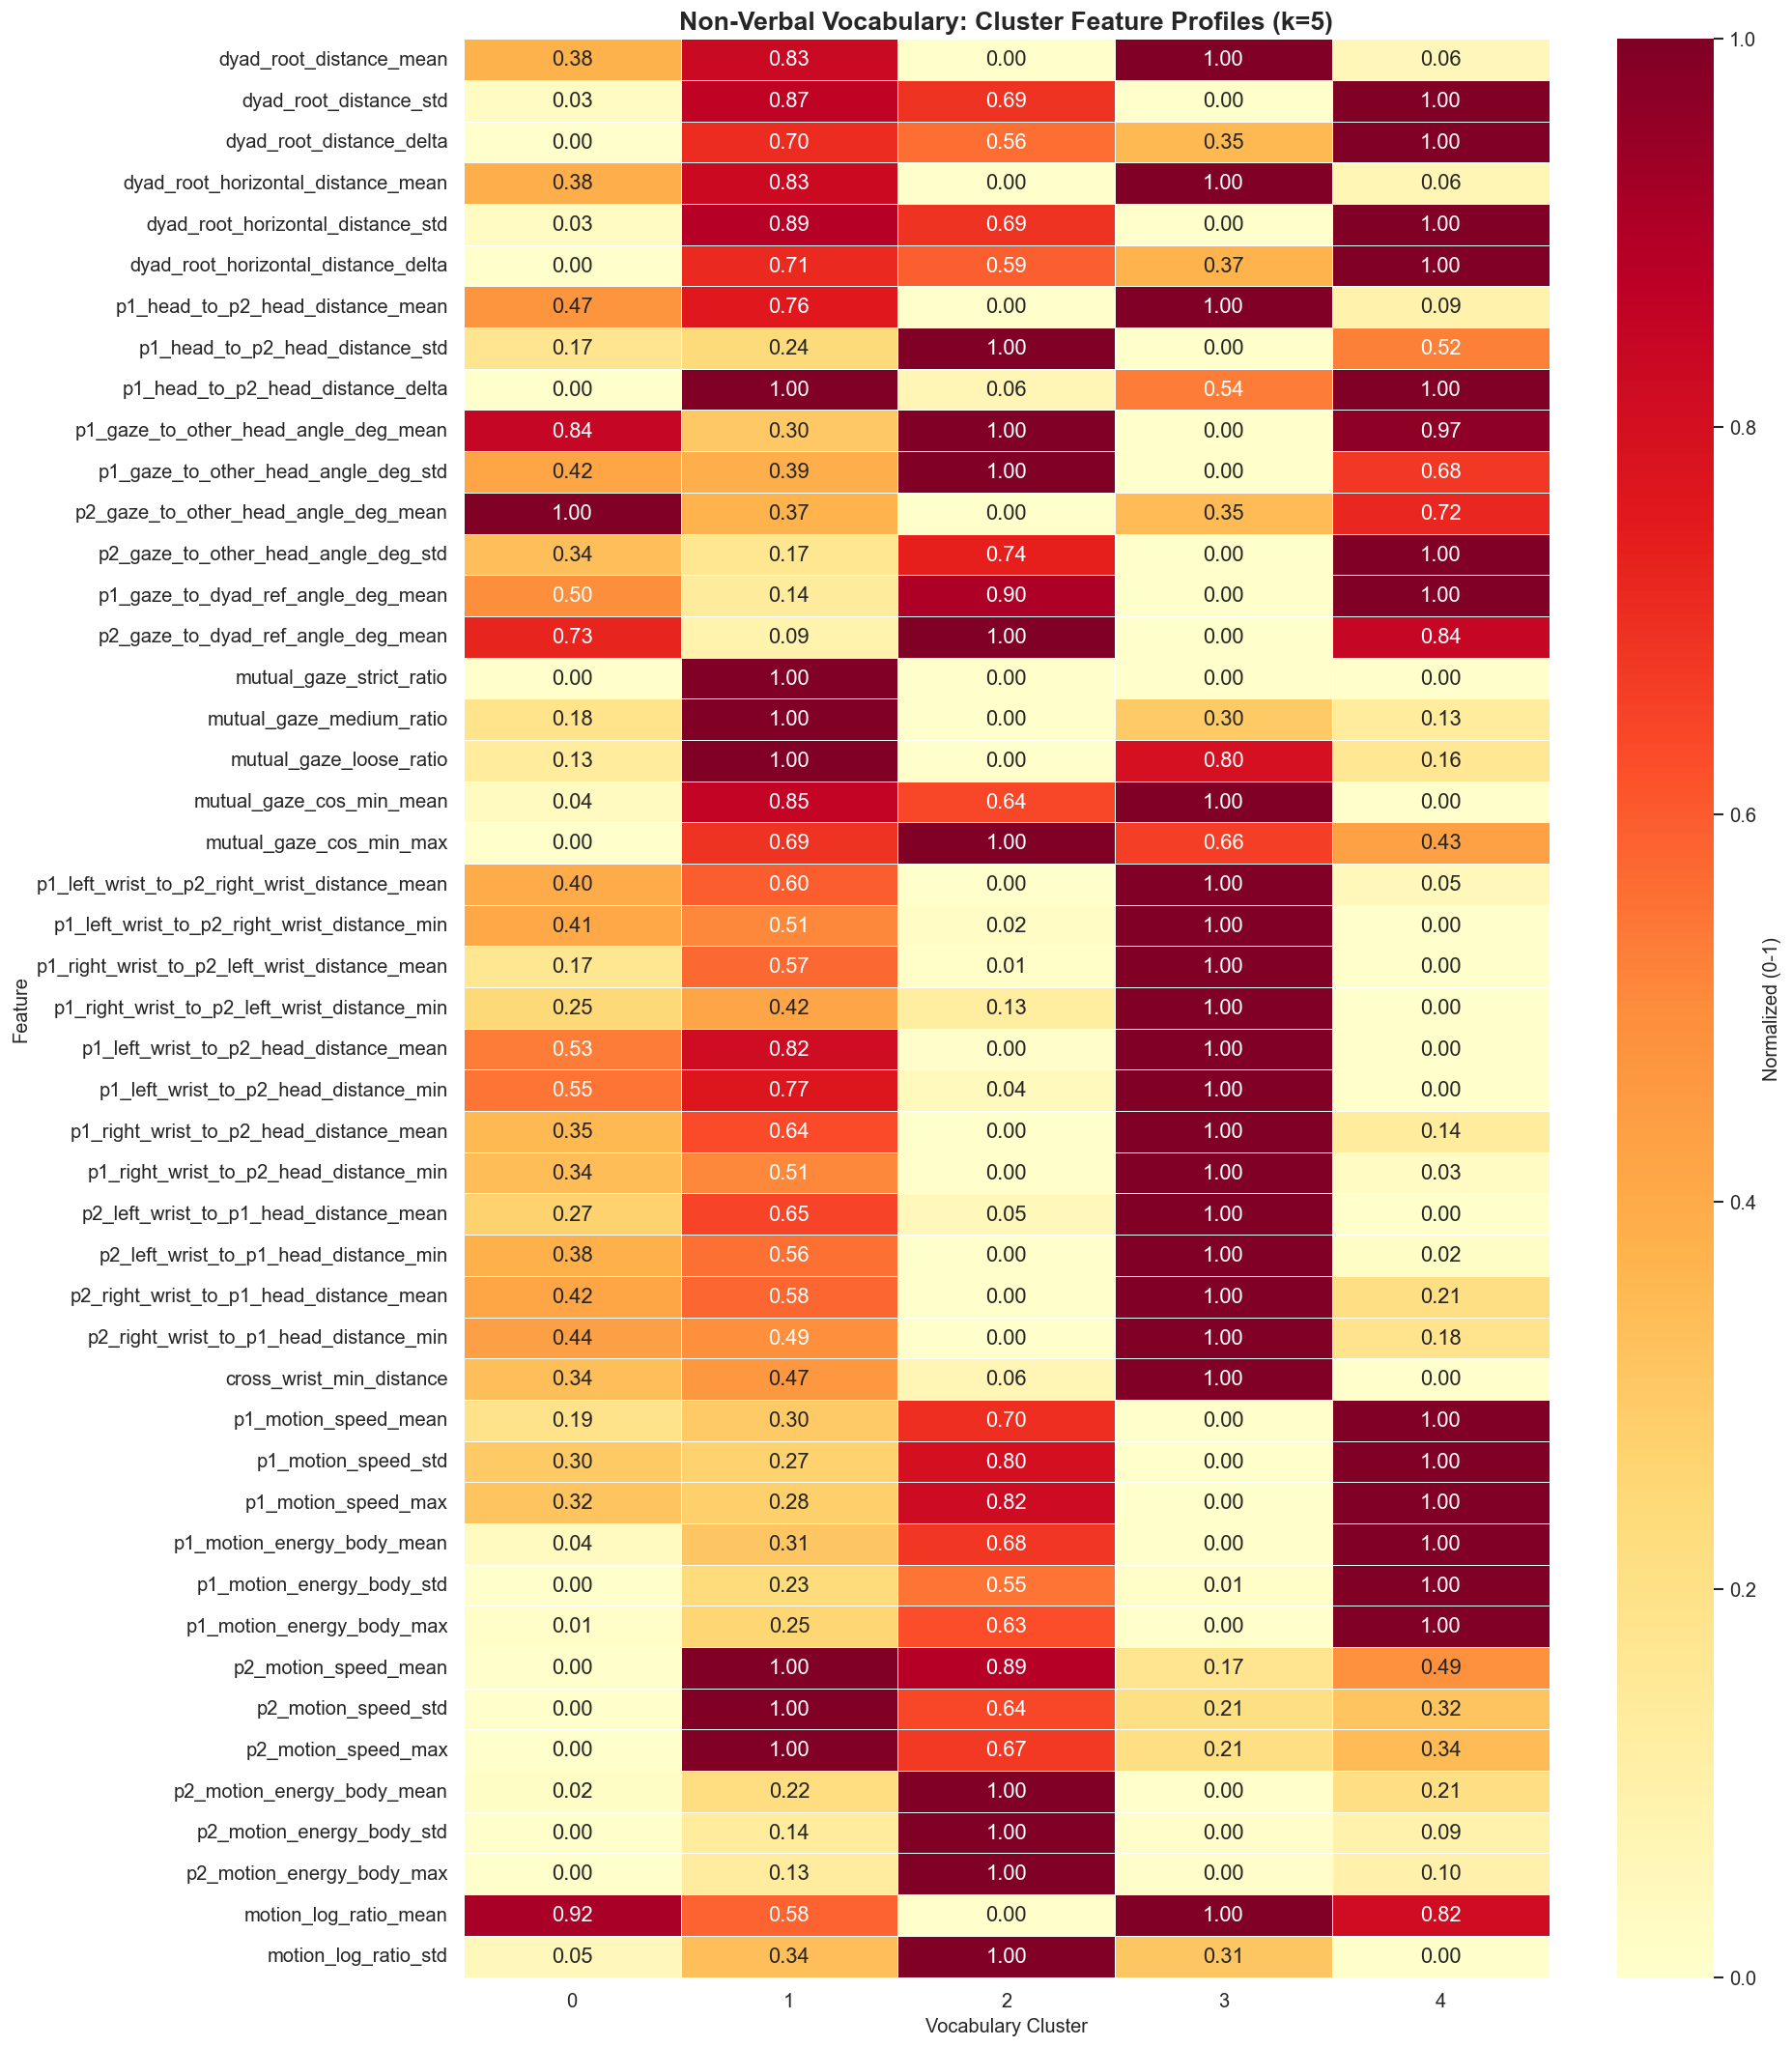

In [15]:
# Profile
meta_cols_all = ['session_label', 'window_start_frame', 'window_end_frame',
                 'window_start_ms', 'window_end_ms', 'cluster', 'pca1', 'pca2',
                 'pca3', 'silhouette', 'vocab_cluster']
profile_cols_v = [c for c in window_clean.columns if c not in meta_cols_all]

profiles_v = window_clean.groupby('vocab_cluster')[profile_cols_v].mean()
profiles_v_norm = (profiles_v - profiles_v.min()) / (profiles_v.max() - profiles_v.min() + 1e-9)

# Reorder by category
cat_order_v = []
cats_v = {
    'Proxemics': [c for c in profile_cols_v if 'dyad_root' in c or 'head_to_p2_head' in c],
    'Gaze': [c for c in profile_cols_v if 'gaze' in c or 'mutual' in c],
    'Kinesics': [c for c in profile_cols_v if 'wrist' in c],
    'Motion': [c for c in profile_cols_v if 'motion' in c],
}
for cat_name, cat_cols in cats_v.items():
    cat_order_v.extend([c for c in cat_cols if c in profiles_v_norm.columns])
remaining_v = [c for c in profiles_v_norm.columns if c not in cat_order_v]
cat_order_v.extend(remaining_v)
profiles_v_norm = profiles_v_norm[cat_order_v]

fig, ax = plt.subplots(figsize=(16, max(12, len(cat_order_v) * 0.38)))
sns.heatmap(profiles_v_norm.T, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized (0-1)'})
ax.set_title(f'Non-Verbal Vocabulary: Cluster Feature Profiles (k={VOCAB_K})',
             fontsize=16, fontweight='bold')
ax.set_ylabel('Feature')
ax.set_xlabel('Vocabulary Cluster')
plt.tight_layout()
plt.savefig('vocabulary_profiles_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


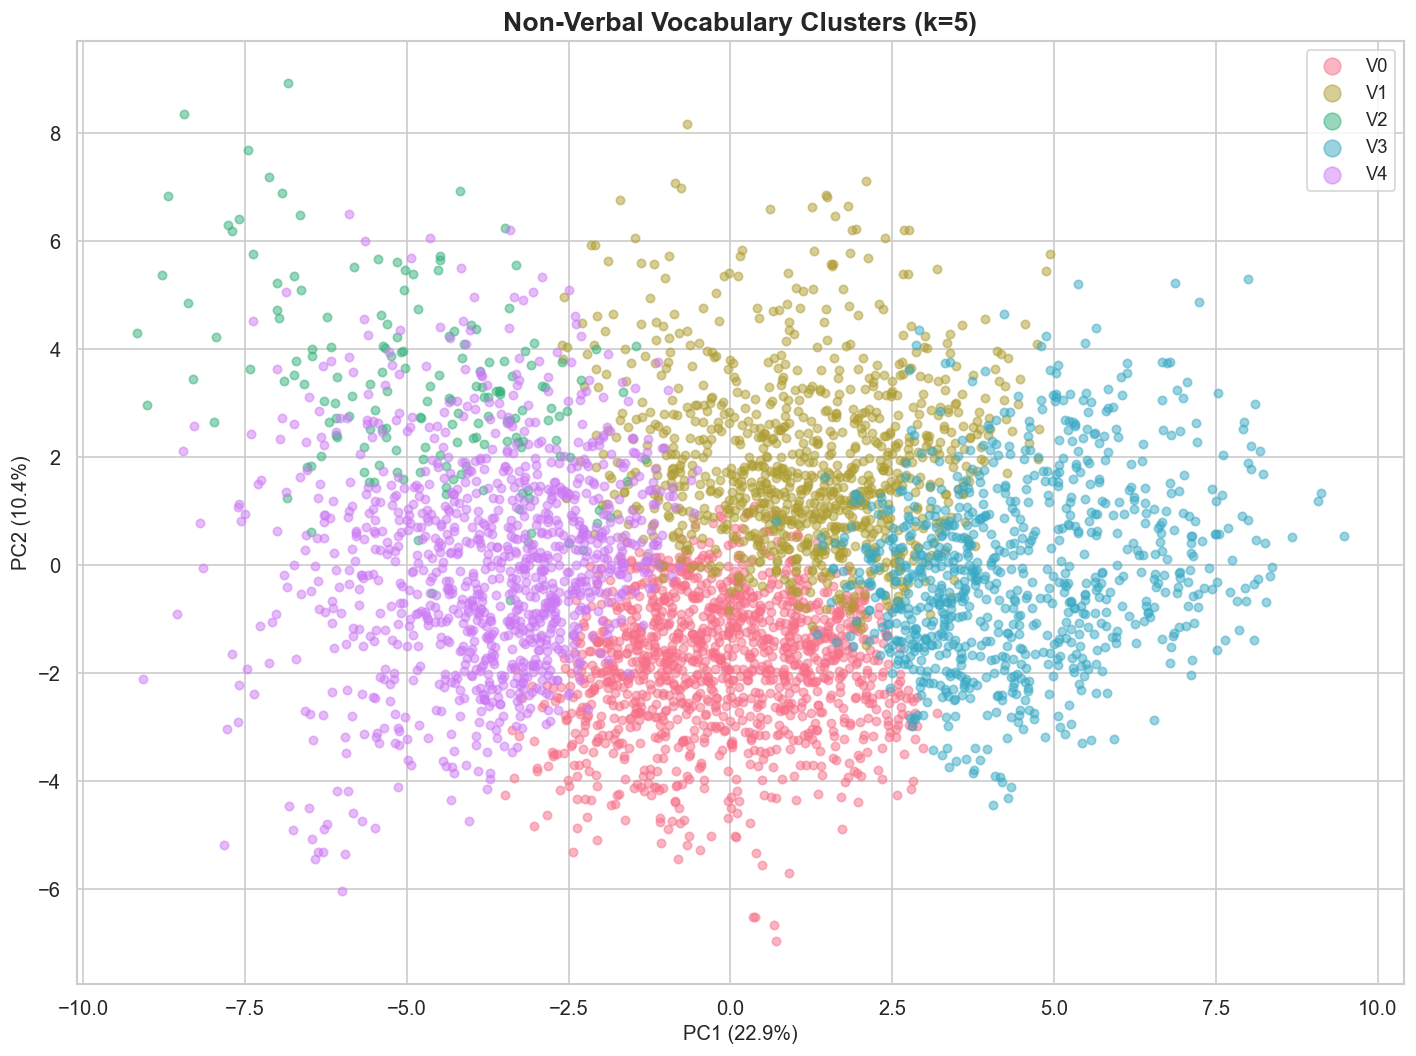

In [16]:
# PCA visualization for vocabulary
pca_v = PCA(n_components=2)
X_pca_v = pca_v.fit_transform(X)
evr_v = pca_v.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(12, 9))
palette_v = sns.color_palette("husl", VOCAB_K)
for i in range(VOCAB_K):
    mask = window_clean['vocab_cluster'] == i
    ax.scatter(X_pca_v[mask, 0], X_pca_v[mask, 1],
               s=25, alpha=0.5, color=palette_v[i], label=f'V{i}')
ax.set_xlabel(f'PC1 ({evr_v[0]:.1%})')
ax.set_ylabel(f'PC2 ({evr_v[1]:.1%})')
ax.set_title(f'Non-Verbal Vocabulary Clusters (k={VOCAB_K})', fontsize=16, fontweight='bold')
ax.legend(fontsize=11, markerscale=2)
plt.tight_layout()
plt.savefig('vocabulary_pca.png', dpi=150, bbox_inches='tight')
plt.show()


### 13.3 Vocabulary Transition Analysis (Markov Chain)

The temporal sequence of vocabulary states reveals the **grammar** of
non-verbal communication: which behaviors typically follow which.


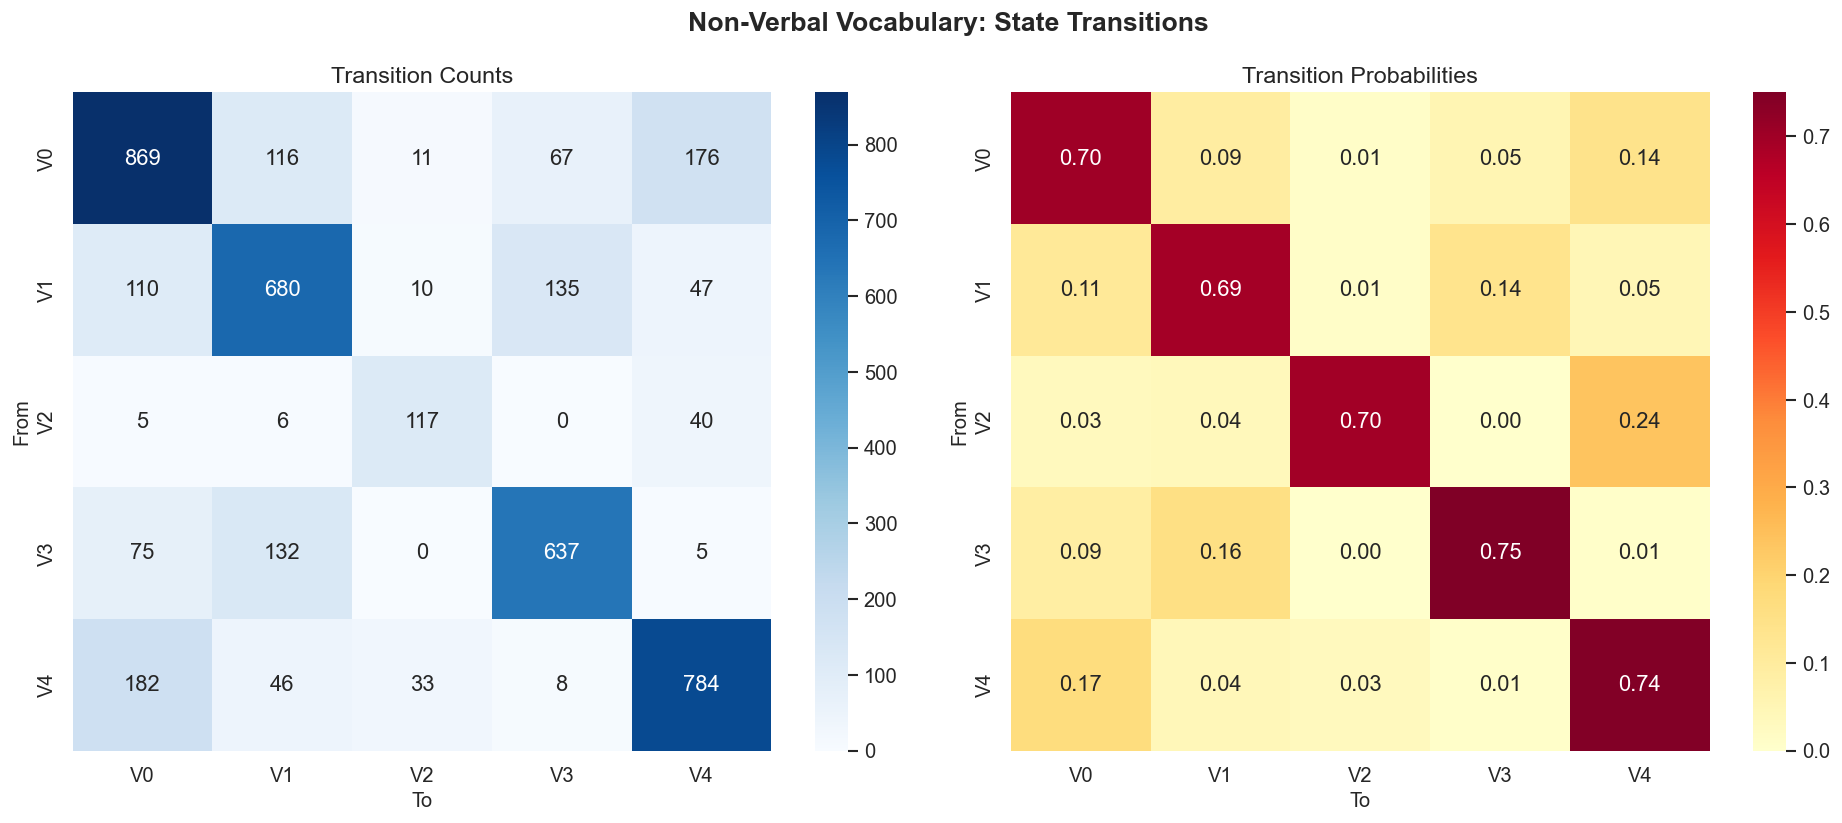

Chi-Squared Test: Are vocabulary transitions non-uniform?
  From V0: chi2= 2006.37, p=0.000000 ***
  From V1: chi2= 1538.54, p=0.000000 ***
  From V2: chi2=  288.85, p=0.000000 ***
  From V3: chi2= 1676.58, p=0.000000 ***
  From V4: chi2= 2038.40, p=0.000000 ***

Transition Entropy:
  V0: H=1.367/2.322  [█████████████████░░░░░░░░░░░░░]  (58.9%)
  V1: H=1.392/2.322  [█████████████████░░░░░░░░░░░░░]  (59.9%)
  V2: H=1.179/2.322  [███████████████░░░░░░░░░░░░░░░]  (50.8%)
  V3: H=1.081/2.322  [█████████████░░░░░░░░░░░░░░░░░]  (46.6%)
  V4: H=1.162/2.322  [███████████████░░░░░░░░░░░░░░░]  (50.0%)


In [17]:
# Transition matrix for vocabulary clusters
trans_v = np.zeros((VOCAB_K, VOCAB_K), dtype=int)
for _, group in window_clean.groupby('session_label'):
    group_sorted = group.sort_values('window_start_frame')
    labels = group_sorted['vocab_cluster'].values
    for j in range(len(labels) - 1):
        trans_v[labels[j], labels[j + 1]] += 1

row_sums_v = trans_v.sum(axis=1, keepdims=True)
row_sums_v[row_sums_v == 0] = 1
T_v = trans_v / row_sums_v

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(trans_v, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'V{i}' for i in range(VOCAB_K)],
            yticklabels=[f'V{i}' for i in range(VOCAB_K)])
axes[0].set_title('Transition Counts'); axes[0].set_xlabel('To'); axes[0].set_ylabel('From')

sns.heatmap(T_v, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1],
            xticklabels=[f'V{i}' for i in range(VOCAB_K)],
            yticklabels=[f'V{i}' for i in range(VOCAB_K)])
axes[1].set_title('Transition Probabilities'); axes[1].set_xlabel('To'); axes[1].set_ylabel('From')

plt.suptitle('Non-Verbal Vocabulary: State Transitions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('vocabulary_transitions.png', dpi=150, bbox_inches='tight')
plt.show()

# Chi-squared test
print("Chi-Squared Test: Are vocabulary transitions non-uniform?")
print("="*60)
for i in range(VOCAB_K):
    observed = trans_v[i]
    if observed.sum() == 0:
        continue
    expected = np.full(VOCAB_K, observed.sum() / VOCAB_K)
    chi2, p = stats.chisquare(observed, expected)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    print(f"  From V{i}: chi2={chi2:8.2f}, p={p:.6f} {sig}")

# Entropy
print(f"\nTransition Entropy:")
max_ent = np.log2(VOCAB_K)
for i in range(VOCAB_K):
    row = T_v[i]
    row_nz = row[row > 0]
    ent = -np.sum(row_nz * np.log2(row_nz))
    ratio = ent / max_ent
    bar = "█" * int(ratio * 30) + "░" * (30 - int(ratio * 30))
    print(f"  V{i}: H={ent:.3f}/{max_ent:.3f}  [{bar}]  ({ratio:.1%})")


In [18]:
# Cross-session consistency for vocabulary clusters
sess_v = window_clean.groupby(['session_label', 'vocab_cluster']).size().unstack(fill_value=0)
print("Cross-Session Consistency (Vocabulary k=5)")
print("="*60)
for i in range(VOCAB_K):
    n_sess = (sess_v[i] > 0).sum()
    total = len(sess_v)
    print(f"  V{i}: appears in {n_sess}/{total} sessions ({n_sess/total*100:.0f}%)")


Cross-Session Consistency (Vocabulary k=5)
  V0: appears in 42/44 sessions (95%)
  V1: appears in 35/44 sessions (80%)
  V2: appears in 8/44 sessions (18%)
  V3: appears in 31/44 sessions (70%)
  V4: appears in 37/44 sessions (84%)


## 14. Complete Evidence Summary

### Hierarchical Structure

| Level | k | Silhouette | Permutation p | Stability (ARI) | Interpretation |
|-------|---|-----------|---------------|-----------------|----------------|
| Macro | 2 | 0.146 | 0.036 * | 0.981 | Two interaction phases |
| Vocabulary | 5 | See §13.1 | See §13.1 | See bootstrap | Five behavioral syllables |

### Evidence Chain (No Ground-Truth Needed)

1. ✅ **Clusters are non-random** — Permutation test significant for both k=2 and k=5
2. ✅ **Clusters are stable** — Bootstrap ARI > 0.95 for k=2
3. ✅ **Transitions are structured** — Chi-squared p < 0.001 for all states
4. ✅ **Patterns generalize** — All clusters appear across multiple sessions
5. ✅ **Literature grounding** — Features derived from established SSP theory

### Recommended Labels (to be refined)

Examine the heatmap in §13.2 and assign labels based on dominant features:

| Cluster | Dominant Signal | Potential Label |
|---------|----------------|-----------------|
| V0 | ??? | TBD — examine heatmap |
| V1 | ??? | TBD — examine heatmap |
| V2 | ??? | TBD — examine heatmap |
| V3 | ??? | TBD — examine heatmap |
| V4 | ??? | TBD — examine heatmap |

### References

1. Vinciarelli et al. (2009) — Social Signal Processing framework
2. Kendon (1967) — Gaze functions in interaction
3. Hall (1966) — Proxemics
4. Sacks, Schegloff & Jefferson (1974) — Turn-taking
5. Rousseeuw (1987) — Silhouette validation
6. Pentland (2008) — Honest signals
7. Wiltschko et al. (2015) — Behavioral syllables
8. Hoffman (2019) — Fluency in human collaboration
9. Argyle & Dean (1965) — Intimacy equilibrium
10. Delaherche et al. (2012) — Interpersonal synchrony
11. Davies & Bouldin (1979) — DB Index
12. Calinski & Harabasz (1974) — CH Index
